# Spotify Track Popularity Project

In [268]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

## A. Introduction

- I solved my project as a classification problem.

- In order to convert this regression problem into a classification problem, I changed the value for my output `track_popularity`. Initially, these values were float variables in the range of 1 to 100. To convert these, I first set a boolean on that variable to test if values were greater than or equal to 50, since that's the threshold I wanted to use to determine if a track was popular(1) or unpopular (0). I set a for-loop to convert the 'True' 'False' statements from my boolean into values of 1 or 0 respectively.

- The major findings I found were that, while this dataset didn't seem to lend itself to straightforward and accurate predictions, some variables impacted the output more than others. For example, when fitting the models, I consistently found that `playlist_genre` (and particularly rock) had a significant slope relative to the others. And my models that included features of `playlist_genre` performed better than those that did not. The finding for **rock** in particular was not what I would have expected because that was the one genre that didn't show any significant correlations between continuous inputs and the output when I performed my correlation heatmaps.

- I think EDA could help identify similar trends and relationships that my model did but this case in particular made it difficult. I say this because my most significant inputs seemed to be `playlist_genre` which was categorical. This made it easy to *group by* the values but trickier to see direct correlations between the genres themselves and the output. However, both my models and EDA were able to show a relationship between the ***edm** genre and the output. This was exemplified by `edm` having a higher count of unpopular tracks than it did for popular, and that all of my models showed the intercept (which was taken from the edm coefficient) had the largest absolute value for its parameter, and it was always negative.

- Clustering was consistent with my conclusions in the fact that it showed this data was difficult to cleanly analyze and predict. So many of the values seemed to overlap with one another, which was evidenced by no model of mine having an accuracy of over 65%.

## B. Reporting on my EDA

In [269]:
spotify_url = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv'

In [270]:
spotify_df = pd.read_csv(spotify_url)

### Before displaying my essential exploration, I'm changing the `track_popularity` column into a categorical one in order to solve a classification problem. 

In [271]:
### First, I'm creating a copy of the Data Frame that will contain its original data before any manipulation took place.

spotify_df_copy = spotify_df.copy()

In [272]:
spotify_df['track_popularity'] = spotify_df.track_popularity >= 50

In [273]:
### Creating a for loop in order to convert all track_popularity values into values 1 and 0

for n in range(len(spotify_df)):
    if spotify_df.track_popularity[n] == True:
        spotify_df.track_popularity[n] = 1
    else:
        spotify_df.track_popularity[n] = 0

C:\Users\abene\AppData\Local\Temp\ipykernel_6732\3863519031.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spotify_df.track_popularity[n] = 1


In [274]:
### I'm now converting the output variable into an integer data type.

spotify_df.track_popularity = spotify_df.track_popularity.astype(int)

- Displaying the number of rows and columns.
- Displaying the column names and their associated data types.
- Displaying the number of missing values for each column.
- Displaying the number of unique values for each column.

In [275]:
spotify_df.shape

(32833, 23)

This dataframe has 32833 rows and 23 columns.

In [276]:
spotify_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int32  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

**Column names and data types are above.**

In [277]:
spotify_df.isna().sum()

track_id                    0
track_name                  5
track_artist                5
track_popularity            0
track_album_id              0
track_album_name            5
track_album_release_date    0
playlist_name               0
playlist_id                 0
playlist_genre              0
playlist_subgenre           0
danceability                0
energy                      0
key                         0
loudness                    0
mode                        0
speechiness                 0
acousticness                0
instrumentalness            0
liveness                    0
valence                     0
tempo                       0
duration_ms                 0
dtype: int64

Track_name, track_artist, and track_album_name all have 5 missing values, while the other variables in the dataset have none.


After displaying those 5 missing values for each variable below, they all correspond with the same 5 rows, meaning if a row is missing one of these variables, then it **also** is missing the other two.

While all tracks have different values for `track_id`, rows **9282** and **9283** are in the same playlist, 'GANGSTA Rap', and share the same `playlist_id`.

All rows have `track_popularity` scores of 0 as well.

Since these missing variables are not any of my input or output variables, I'm electing to keep these 5 rows in my dataset.

In [278]:
spotify_df.loc[(spotify_df.track_name.isna() == True) | 
               (spotify_df.track_artist.isna() == True) | 
               (spotify_df.track_album_name.isna() == True)]

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
8151,69gRFGOWY9OMpFJgFol1u0,NaN,NaN,0,717UG2du6utFe7CdmpuUe3,NaN,2012-01-05,HIP&HOP,5DyJsJZOpMJh34WvUrQzMV,rap,...,6,-7.635,1,0.1760,0.0410,0.00000,0.1160,0.649,95.999,282707
9282,5cjecvX0CmC9gK0Laf5EMQ,NaN,NaN,0,3luHJEPw434tvNbme3SP8M,NaN,2017-12-01,GANGSTA Rap,5GA8GDo7RQC3JEanT81B3g,rap,...,11,-5.364,0,0.3190,0.0534,0.00000,0.5530,0.191,146.153,202235
9283,5TTzhRSWQS4Yu8xTgAuq6D,NaN,NaN,0,3luHJEPw434tvNbme3SP8M,NaN,2017-12-01,GANGSTA Rap,5GA8GDo7RQC3JEanT81B3g,rap,...,10,-5.907,0,0.3070,0.0963,0.00000,0.0888,0.505,86.839,206465
19568,3VKFip3OdAvv4OfNTgFWeQ,NaN,NaN,0,717UG2du6utFe7CdmpuUe3,NaN,2012-01-05,Reggaeton viejito🔥,0si5tw70PIgPkY1Eva6V8f,latin,...,11,-6.075,0,0.0366,0.0606,0.00653,0.1030,0.726,97.017,252773
19811,69gRFGOWY9OMpFJgFol1u0,NaN,NaN,0,717UG2du6utFe7CdmpuUe3,NaN,2012-01-05,latin hip hop,3nH8aytdqNeRbcRCg3dw9q,latin,...,6,-7.635,1,0.1760,0.0410,0.00000,0.1160,0.649,95.999,282707


#### Number of unique values are below.

In [279]:
spotify_df.nunique()

track_id                    28356
track_name                  23449
track_artist                10692
track_popularity                2
track_album_id              22545
track_album_name            19743
track_album_release_date     4530
playlist_name                 449
playlist_id                   471
playlist_genre                  6
playlist_subgenre              24
danceability                  822
energy                        952
key                            12
loudness                    10222
mode                            2
speechiness                  1270
acousticness                 3731
instrumentalness             4729
liveness                     1624
valence                      1362
tempo                       17684
duration_ms                 19785
dtype: int64

Although **mode** and **key** are both numeric values, I'll treat them as categoricals due to their low unique value counts of 2 and 12 respectively.

### Counts for my output variable:

In [280]:
spotify_df.track_popularity.value_counts()

track_popularity
0    18373
1    14460
Name: count, dtype: int64

There are nearly 4000 more counts of **unpopular** tracks compared to **popular** ones. 

C:\Users\abene\anaconda3\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


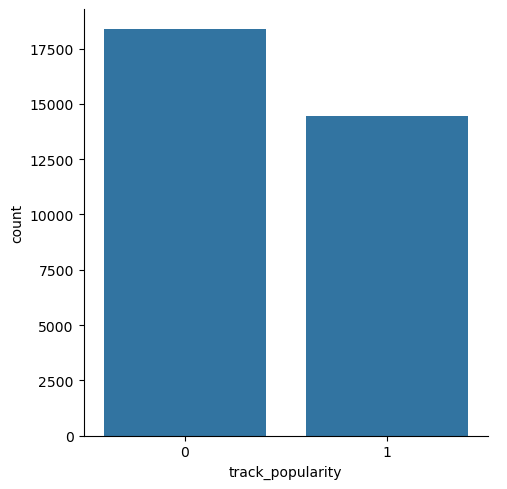

In [281]:
sns.catplot(data=spotify_df, x='track_popularity', kind='count')

plt.show()

I'm displaying this information below to highlight that the original dataset contained 2620 unique tracks with `track_popularity` scores of exactly 0. In my full EDA, I explored whether removing these values made a substantial impact on the correlations with the output variable. Since they did not, I'm leaving them in my dataset and assuming that they were recorded accurately.

In [282]:
spotify_df_copy.loc[spotify_df_copy.track_popularity == 0].track_id.nunique()

2620

#### Counts of categorical variables

C:\Users\abene\anaconda3\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


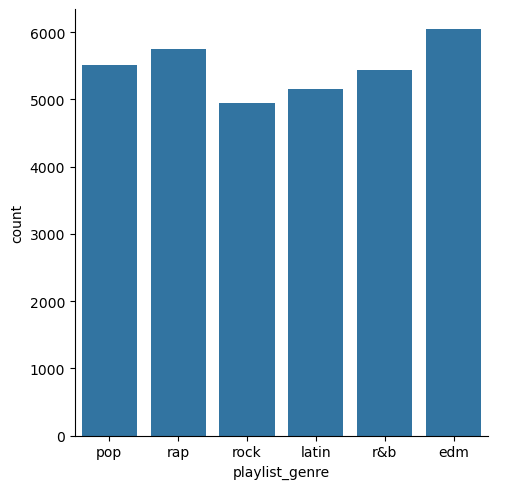

In [283]:
sns.catplot(data=spotify_df, x='playlist_genre', kind='count')

plt.show()

C:\Users\abene\anaconda3\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


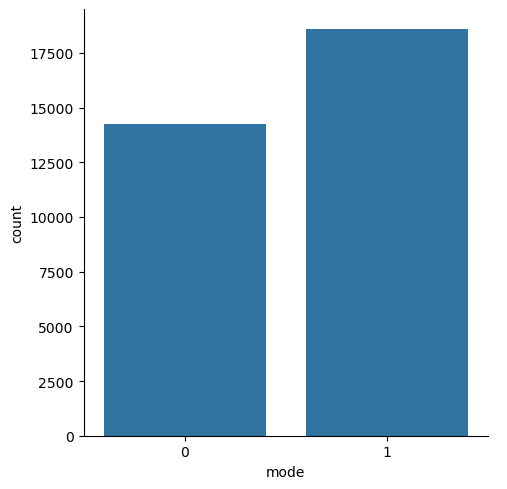

In [284]:
sns.catplot(data=spotify_df, x='mode', kind='count')

plt.show()

### Counts for the outcome when GROUPED by playlist_genre

My EDA shows figures where counts for the outcome are grouped by all three categorical variables. For this notebook, I'm only keeping the figure for `playlist_genre`. This figure reflects the difficulties with this data set, mainly that there doesn't seem to be a significant relationship between the genres and outcome, EXCEPT for edm. There is a significant increase in **unpopular** tracks when the genre is **edm**. 

C:\Users\abene\anaconda3\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


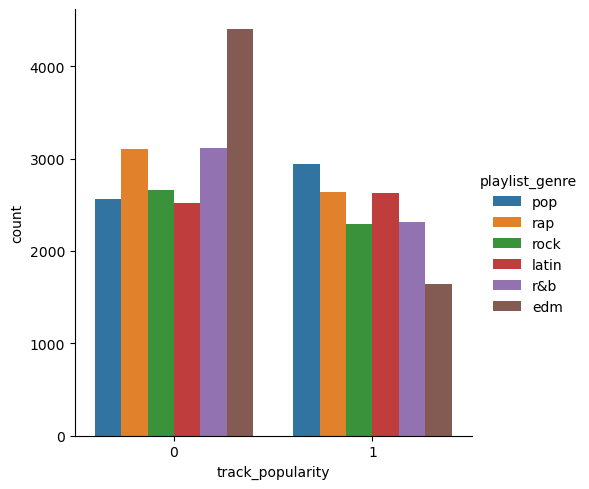

In [285]:
sns.catplot(data=spotify_df, x='track_popularity', hue='playlist_genre', kind='count')

plt.show()

### Distributions for continuous variables

I'm reshaping `spotify_df` into long format to help visualize the marginal continuous distributions.

In [286]:
spotify_numerical = spotify_df.select_dtypes('number').columns.tolist()

In [287]:
spotify_categorical = spotify_df.select_dtypes('object').columns.tolist()

In [288]:
spotify_lf = spotify_df.reset_index().\
rename(columns={'index':'rowid'}).\
melt(id_vars=['rowid']+spotify_categorical, 
    value_vars=spotify_numerical)

Firstly, I'm displaying histograms to visualize the distributions of the counts. I've laid out my analysis for each chart below this figure. 

C:\Users\abene\anaconda3\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


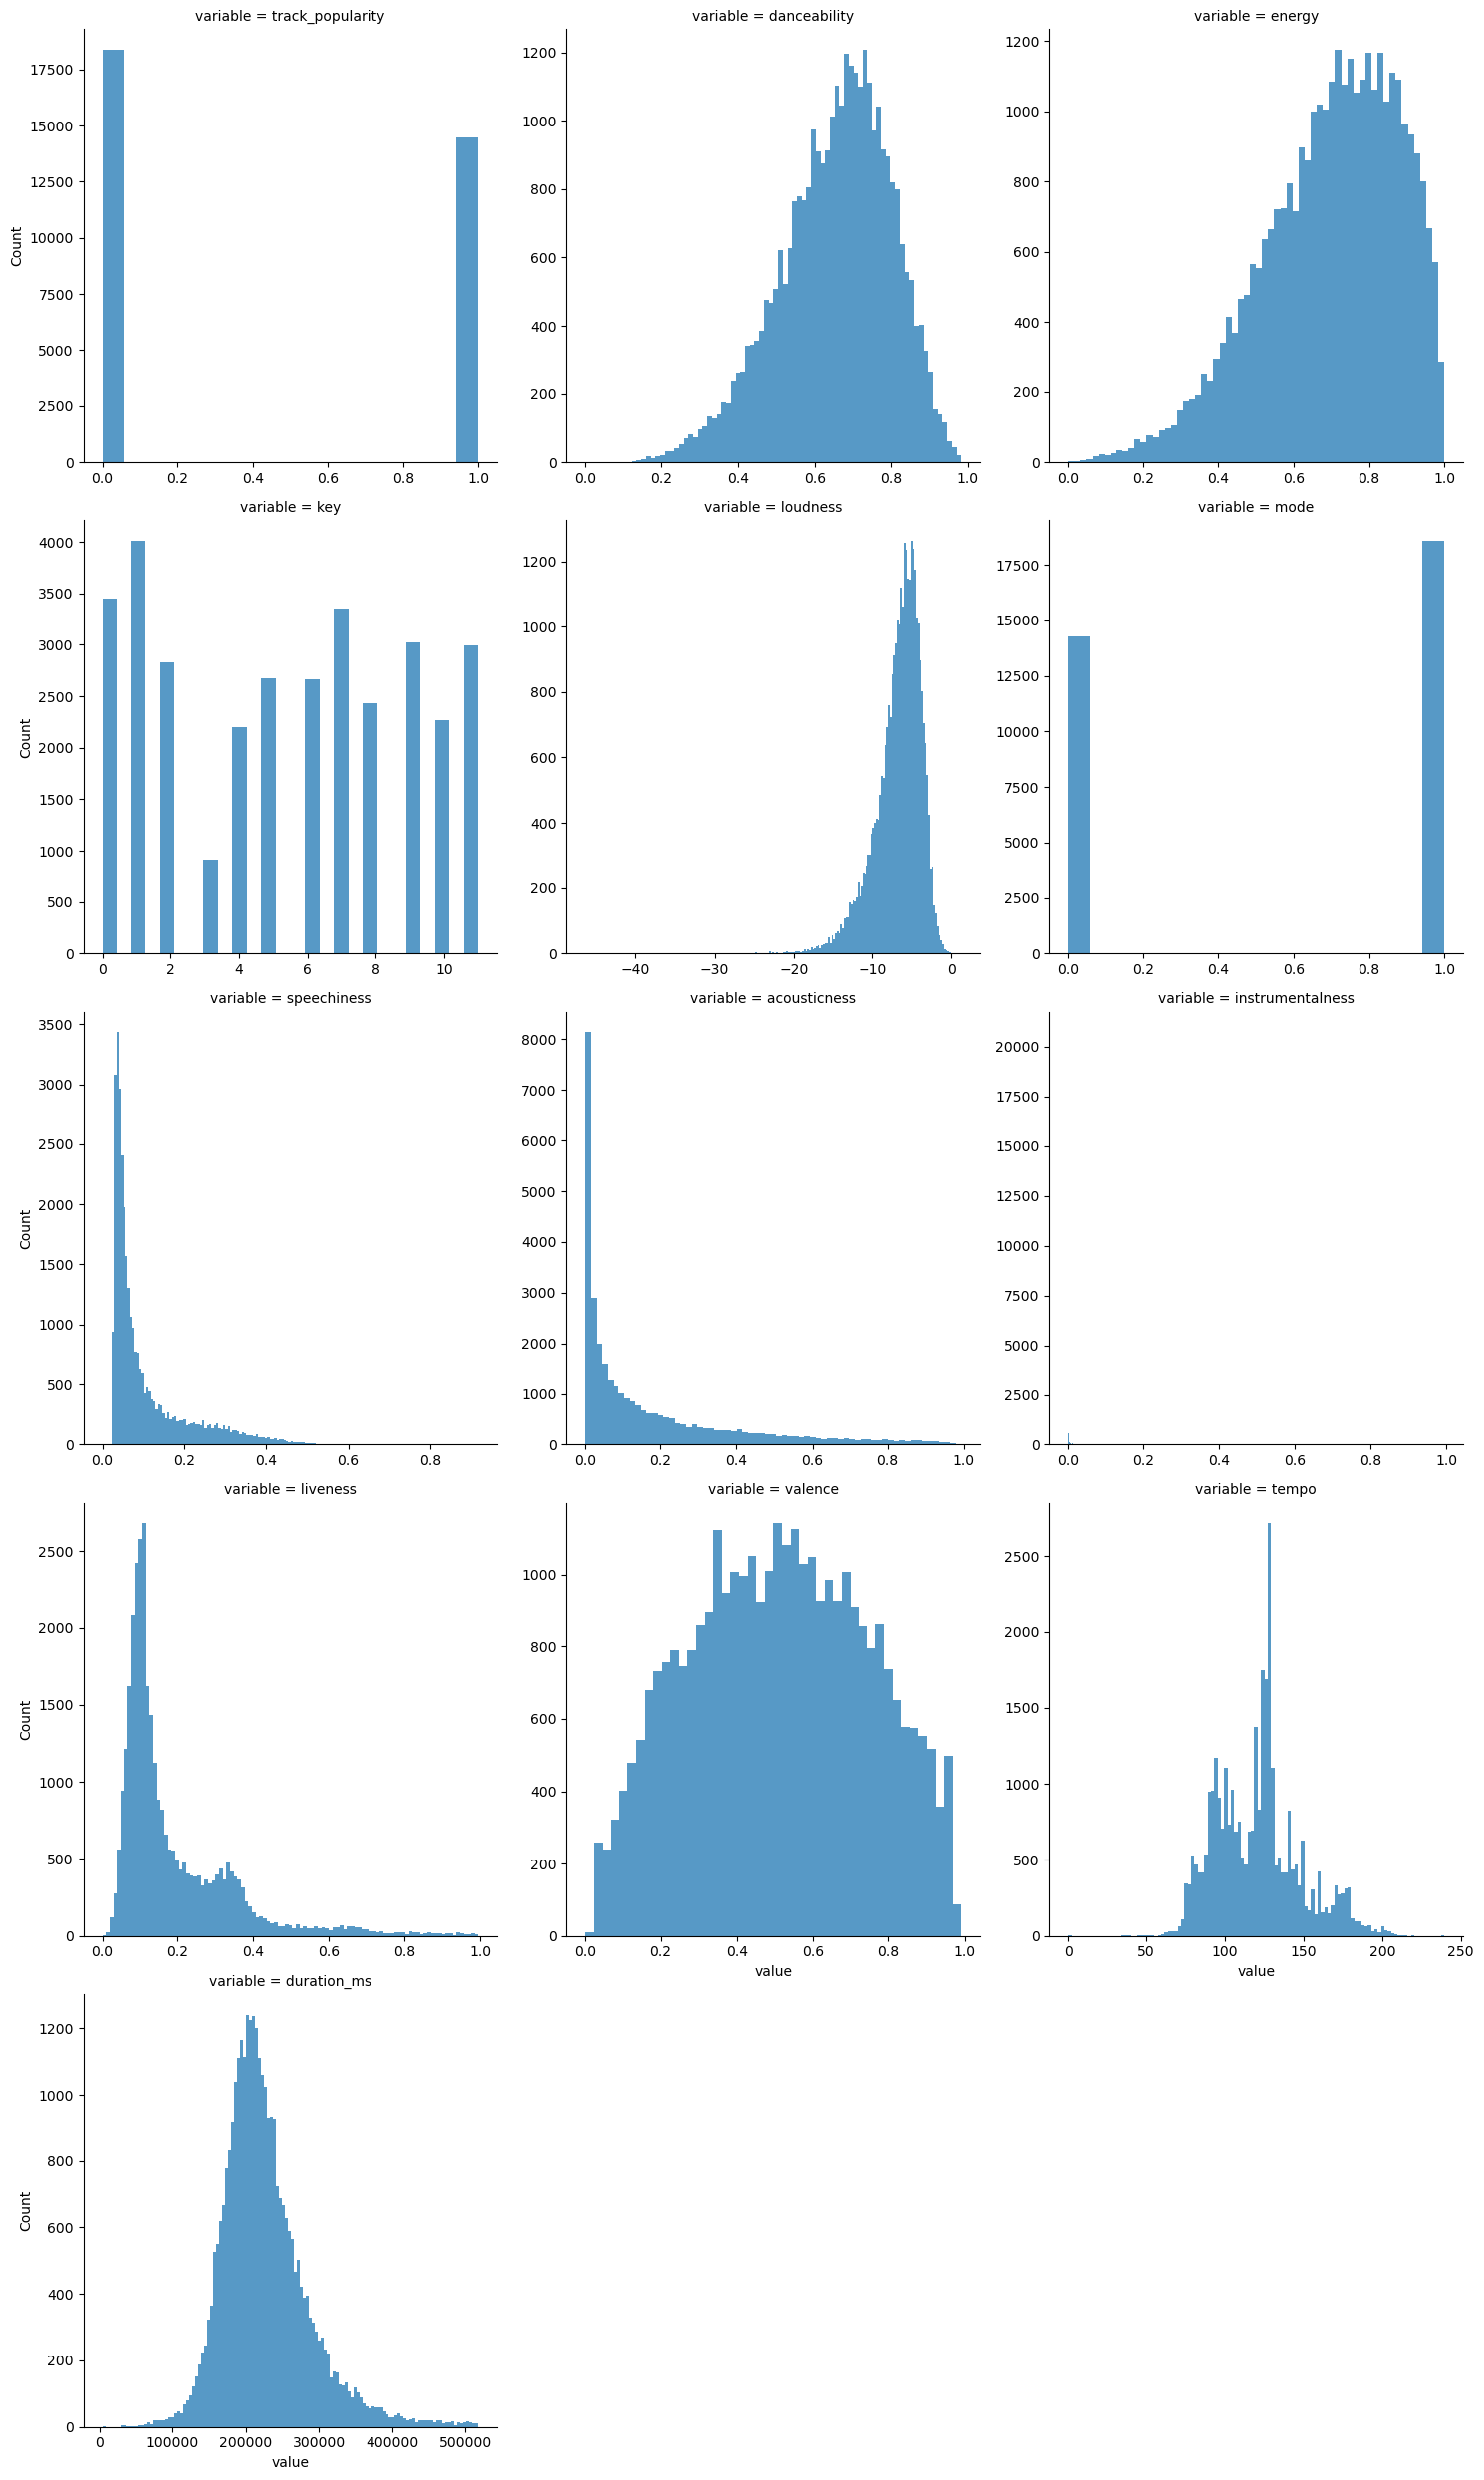

In [289]:
sns.displot(data=spotify_lf, x='value', col='variable', kind='hist', 
           col_wrap=3, facet_kws={'sharex': False, 'sharey': False}, 
           common_bins=False)

plt.show()

### Track popularity
This is my output variable. My analysis of the data can be found earlier in this notebook.

### Danceability
Danceability has a near Gaussian shape but it's skewed to the right. There's a high concentration of tracks with danceability ratings at around 0.7 to 0.8

### Energy
This distribution is similar to danceability, except with a much more severe skew to the right. The vast majority of tracks in this data have high ratings for energy.

### Key
This is a categorical variable and will be elaborated on in the next section.

### Loudness
This distribution has a very sharp, pointed rise starting at around -10 and crashing down soon after its peak at around -8. The values for this variable are all very closely packed.

### Mode
This is a categorical variable and will be elaborated on in the next section.


### Speechiness
Sharp spike at the beginning, with a sharp, but slightly more gradual tail off. There are very few values passed the halfway point of the x-axis, ignifying that the vast majority of songs in this dataset are not very wordy.

### Acousticness
Very similar distribution to speechiness, albeit with a slower tail off.

### Liveness
An early peak at around 0.1, showing that the majority of values concentrate around there. There's a fairly steep drop off within the first half of its x-axis and consistently low values in the 2nd half, indicating relatively light liveness in these tracks.

### Valence
Perhaps the closest distribution we have to a Gaussian one. Most of the values are concentrated in the center, with gradual declines on either side of it.

### Tempo
Almost all values are graduated near the center, with a very sharp rise in the center, indicating that there's a middle-ground tempo that seems to be a common trend or sweet spot amongst tracks.

### Duration_ms
Another near-Gaussian distribution, however, the center peaks too sharply. Most tracks in this dataset are in a goldilocks track time, however there are many outliers at the high end and some on the low.
### Instrumentalness
The larger figure below couldn't convey the distribution of this variable well because of its particular spread. I've created a separte chart for it below, having reduced the bin size to 5. Now, we can clearly see that there's a very large chunk of values in the range of 0.0 to 0.2, suggesting that the vast majority of the tracks in the dataset do not have very high rates of instrumentalness.

C:\Users\abene\anaconda3\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


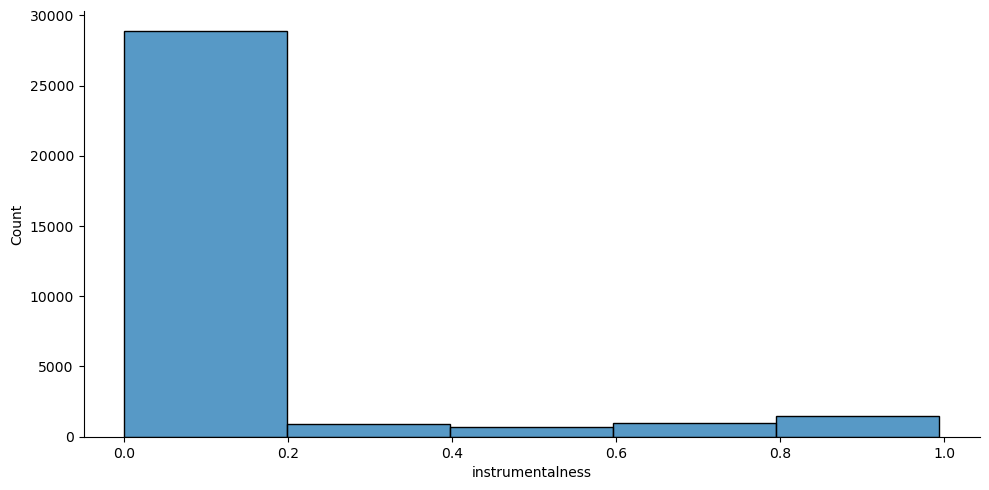

In [290]:
sns.displot(data=spotify_df, x='instrumentalness', kind='hist', bins=5, aspect=2)

plt.show()

Following up on the insights from the `instrumentalness` distribution shown above, I filtered the dataframe to show me the tracks that have instrumentalness values of 0 **outside** of the traditionally known genres to not contain much instrumentation. On the face of this exploration alone, the result makes me skeptical that this variable was tracked accurately, given the inclusion of genres like rock and r&b.

In [291]:
spotify_df.loc[(spotify_df.instrumentalness == 0) & 
               (spotify_df.playlist_genre != 'pop') & 
               (spotify_df.playlist_genre != 'edm') & 
              (spotify_df.playlist_genre != 'rap')]

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
11277,0ivarc4umuzp5I3J7lPDJc,Attitude,Guns N' Roses,0,4ieR19hRkKeE81CalJPQNu,The Spaghetti Incident?,1993-01-01,This Is Guns N' Roses,37i9dQZF1DX74DnfGTwugU,rock,...,1,-2.533,1,0.0938,0.000249,0.0,0.3310,0.613,187.766,87000
11301,65PbE3qfKElGTcweQMmbzf,Sleeping Child - 2014 Remastered Version,Michael Learns To Rock,0,01jdXmJaiRf52DRqTExXhY,25,2014-10-25,Michael Learns To Rock album,22XKr7O6bzSA5bHiwRCPNK,rock,...,2,-11.366,1,0.0248,0.073600,0.0,0.0630,0.904,92.939,216000
11302,6lxOK8iqm78PEN2bXcjSEK,25 Minutes - 2014 Remastered Version,Michael Learns To Rock,0,01jdXmJaiRf52DRqTExXhY,25,2014-10-25,Michael Learns To Rock album,22XKr7O6bzSA5bHiwRCPNK,rock,...,6,-10.210,1,0.0252,0.048000,0.0,0.1050,0.183,163.453,264000
11304,4N73fgEEennudER9hXnHOI,Out of the Blue - 2014 Remastered Version,Michael Learns To Rock,0,01jdXmJaiRf52DRqTExXhY,25,2014-10-25,Michael Learns To Rock album,22XKr7O6bzSA5bHiwRCPNK,rock,...,11,-9.719,1,0.0237,0.235000,0.0,0.0901,0.352,80.091,241000
11305,4qg1esFGKNCCRYGVVNrIin,That's Why (You Go Away) - 2014 Remastered Ver...,Michael Learns To Rock,0,01jdXmJaiRf52DRqTExXhY,25,2014-10-25,Michael Learns To Rock album,22XKr7O6bzSA5bHiwRCPNK,rock,...,7,-11.203,1,0.0264,0.331000,0.0,0.0866,0.336,126.998,254000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26773,7vl6ANTdLHg94AvCYXiSIw,Pray,JRY,1,5VML6S956h4YfoYPooqLEi,Fifty Shades Darker (Original Motion Picture S...,2017-02-10,Sexy Soul 2020,5EMARioe9z9eKOeWIAC2JW,r&b,...,6,-6.994,1,0.0474,0.087500,0.0,0.0917,0.480,82.921,200813
26776,29zBeRiLVnkDEj7tvmLVOU,Fall In Line (feat. Demi Lovato),Christina Aguilera,1,7MfUiQkVEDkOSmU83A2C9q,Liberation,2018-06-15,Sexy Soul 2020,5EMARioe9z9eKOeWIAC2JW,r&b,...,9,-4.701,0,0.0769,0.209000,0.0,0.2770,0.197,123.042,248544
26778,6i7ZCerJICjhpbisBz1Lw4,Slow Dance,Kelly Clarkson,0,6GBu7GU6dztLYlZuUHiwA2,Meaning Of Life,2017-10-27,Sexy Soul 2020,5EMARioe9z9eKOeWIAC2JW,r&b,...,8,-8.137,1,0.0770,0.191000,0.0,0.4130,0.431,187.746,220200
26785,1dPUQhlNGEaDm9Qi1vcL7I,And I Love Him,Esther Phillips,0,4NscNwWLaJ6cVqJFICjR8y,And I Love Him,2005-07-26,Sexy Soul 2020,5EMARioe9z9eKOeWIAC2JW,r&b,...,3,-10.726,0,0.0262,0.309000,0.0,0.0829,0.602,106.370,158733


### Continuous to continuous relationships, grouped by categoricals

In [292]:
group1 = ['pop', 'rap', 'rock']

In [293]:
group2 = ['latin', 'r&b', 'edm']

In [294]:
corr_per_genre = spotify_df.groupby('playlist_genre').corr(numeric_only=True)

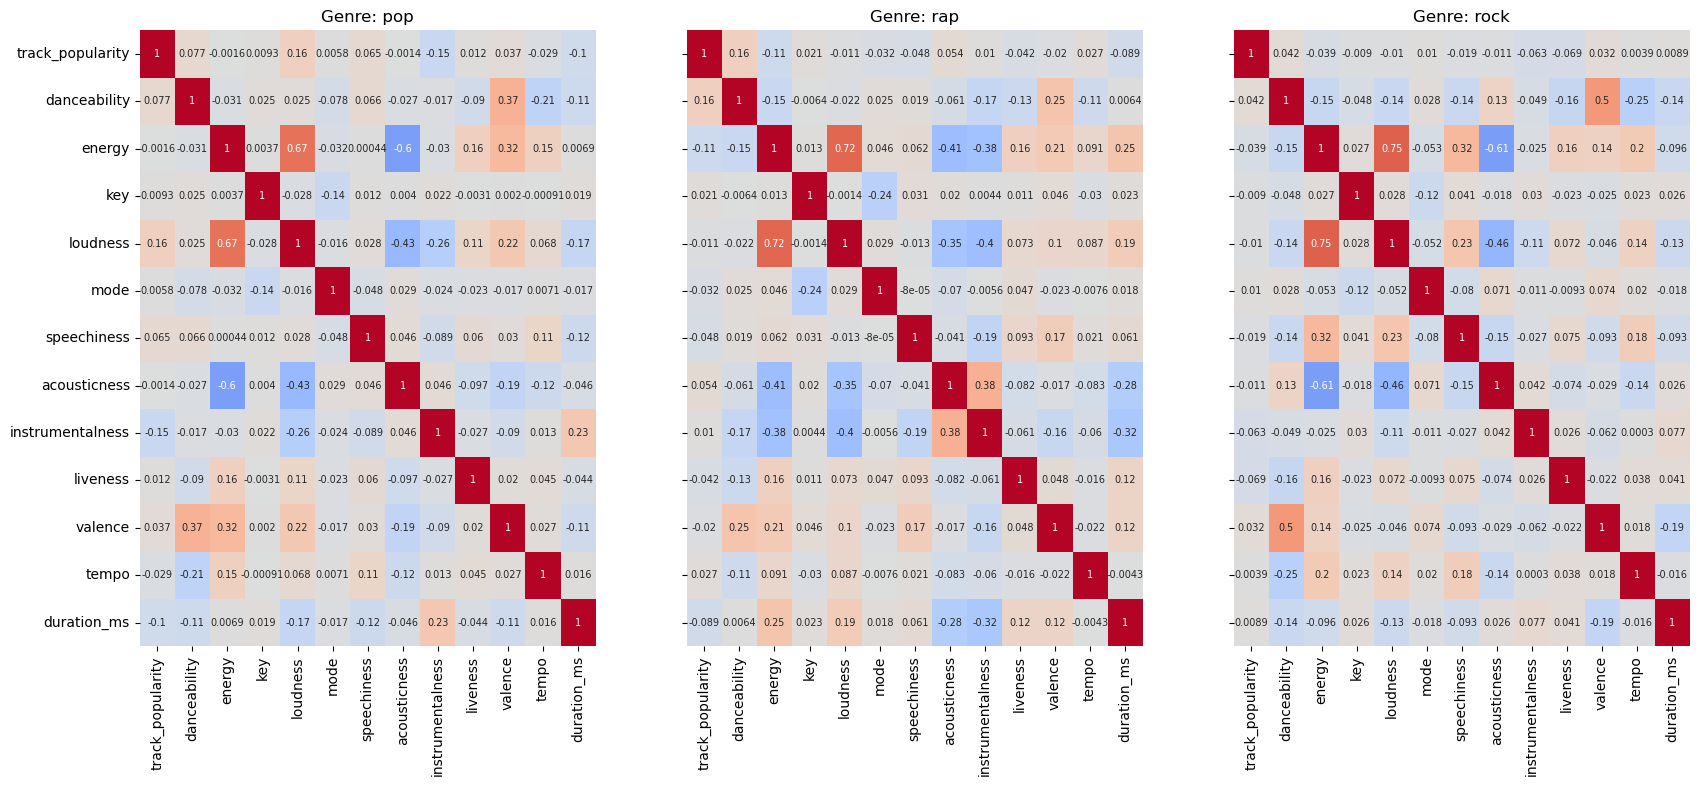

In [295]:
fig, axs = plt.subplots(1, len(group1), figsize=(20, 8), sharex=True, sharey=True)

for n in range(len(group1)):
    sns.heatmap(data=corr_per_genre.loc[group1[n]], 
                vmin=-1, vmax=1, center=0, cmap='coolwarm', cbar=False, 
                annot=True, annot_kws={'size': 7}, ax=axs[n])
    axs[n].set_title('Genre: %s' % group1[n])
plt.show()

For these visualizations, I only want to focus on the correlation between `track_popularity` and the various inputs. While not overly substantial correlations, this visualization shows the following noticeable data:

#### Pop:
- Loudness has a 16% positive correlation with popularity
- Instrumentalness has a 15% negative correlation with popularity
- Duration_ms has a 10% negative correlation

#### Rap:
- Danceability has a 16% positive correlation with popularity
- Energy has an 11% negative correlation

#### Rock:
- No input goes above the 10% correlation mark, either positive or negative

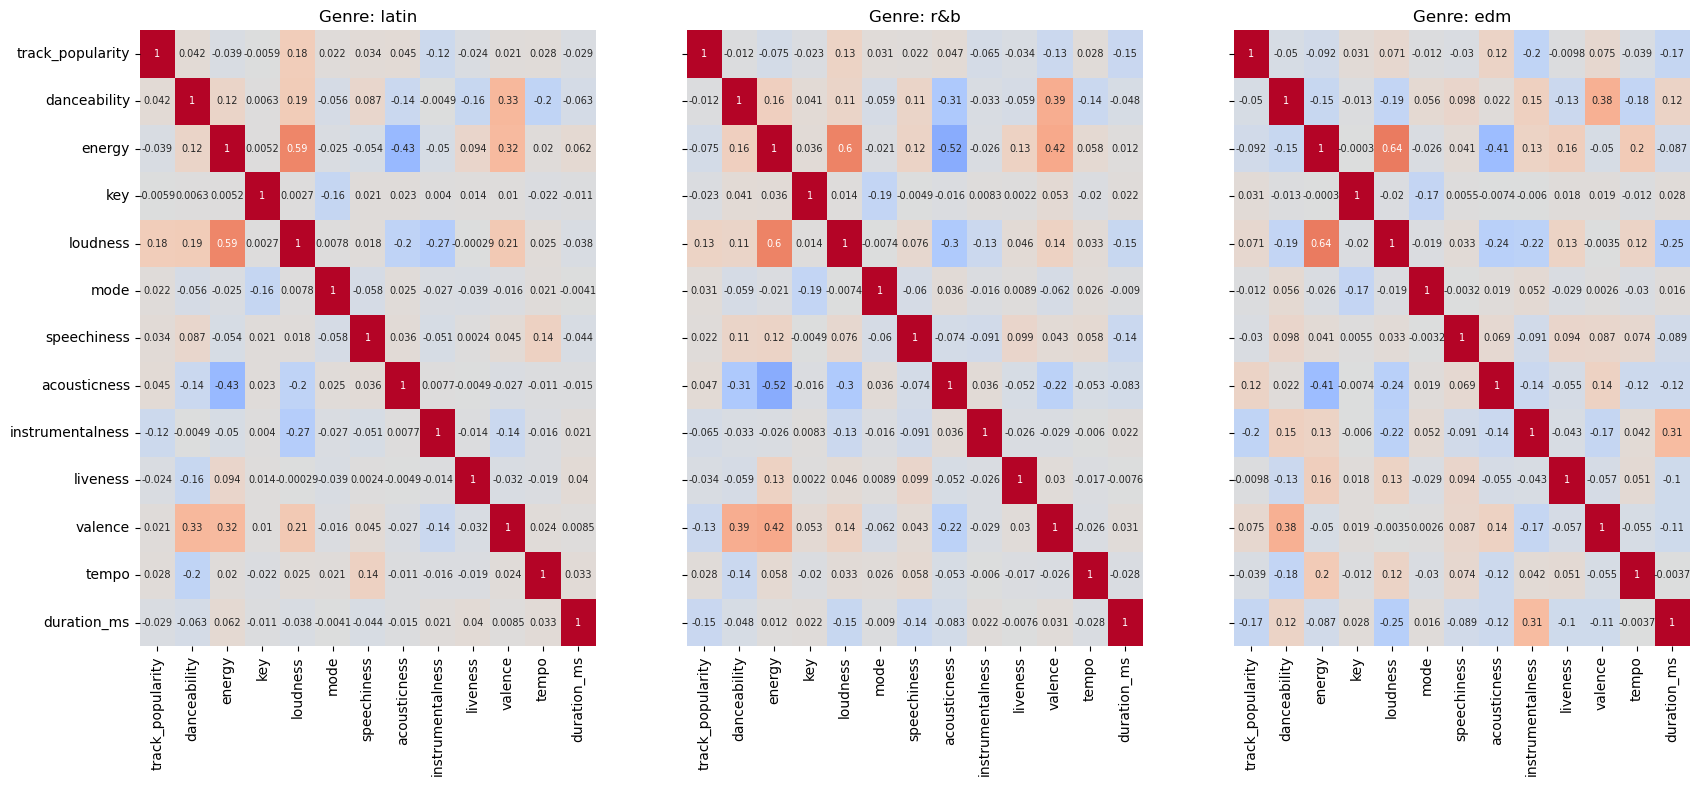

In [296]:
fig, axs = plt.subplots(1, len(group2), figsize=(20, 8), sharex=True, sharey=True)

for n in range(len(group2)):
    sns.heatmap(data=corr_per_genre.loc[group2[n]], 
                vmin=-1, vmax=1, center=0, cmap='coolwarm', cbar=False, 
                annot=True, annot_kws={'size': 7}, ax=axs[n])
    axs[n].set_title('Genre: %s' % group2[n])
plt.show()

#### Latin:
- Loudness has a 18% positive correlation
- Instrumentalness has a 12% negative correlation

#### R&B:
- Loudness has a 13% positive correlation with popularity
- Valence has a 13% negative correlation
- Duration_ms has a 15% negative correlation

#### EDM:
- Acousticness has a positive 12% correlation 
- Instrumentalness has a negative 20% correlation
- Duration_ms has a negative 17% correlation

### Continuous to continuous relationships, grouped by OUTCOME

In [297]:
class_outcome = [0, 1]

In [298]:
corr_per_classification = spotify_df.groupby('track_popularity').corr(numeric_only=True)

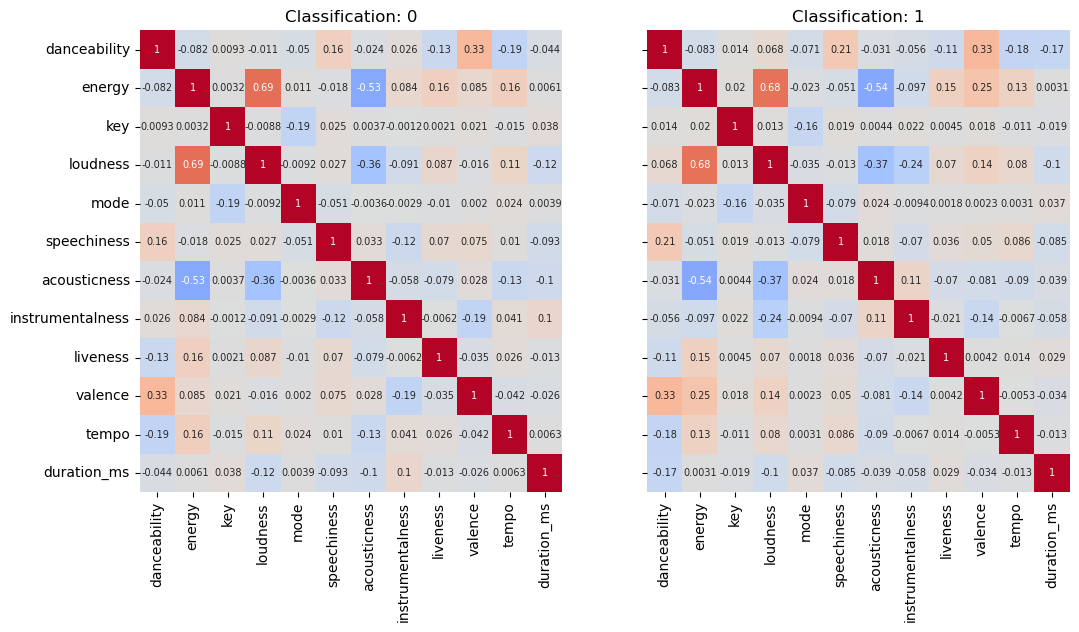

In [299]:
fig, axs = plt.subplots(1, len(class_outcome), figsize=(12, 6), sharex=True, sharey=True)

for n in range(len(class_outcome)):
    sns.heatmap(data=corr_per_classification.loc[class_outcome[n]], 
                vmin=-1, vmax=1, center=0, cmap='coolwarm', cbar=False, 
                annot=True, annot_kws={'size': 7}, ax=axs[n])
    axs[n].set_title('Classification: %s' % class_outcome[n])
plt.show()

When grouped by outcome, there are a few correlations with absolute values greater than 30:

#### Unpopular Tracks
- Loudness and energy: Positive 69% correlation
- Valence and danceability: Positive 33% correlation
- Acousticness and energy: Negative 53% correlation
- Acousicness and loudness: Negative 36% correlation


#### Popular Tracks
- Loudness and energy: Positive 68% correlation
- Valence and danceability: Positive 33% correlation
- Acousticness and energy: Negative 54% correlation
- Acousicness and loudness: Negative 37% correlation

There isn't too much variance between these relationships when grouped by outcome, **HOWEVER**, there's two changes with swings in absolute value of greater than 20%:

- When grouped by the unpopular tracks, there's a **negative 0.09%** correlation between *instrumentalness and loudness.*
- When grouped by the popular tracks, there's a **negative 24%** correlation between *instrumentalness and loudness.*
                                                 &
- When grouped by the unpopular tracks, there's a **positive 0.09%** correlation between *valence and energy.*
- When grouped by the popular tracks, there's a **positive 25%** correlation between *valence and energy.*

###	Summaries of the continuous variables grouped by categorical variables AND **outcomes**

The following 7 figures below show the summary statistics of many of the continuous inputs for each `playlist_genre` when grouped by their classification outcomes.

I included the figures that showed significant and/or consistent variances in the summary statistics when grouped by the different outcomes. I was less interested in how the values varied per genre, and was much more interested in how they varied on whether or not the track was classified as popular or not. As these figures show, the average values for many of the inputs changed signiciantly when the tracks were classified as popular compared to when they weren't.

C:\Users\abene\AppData\Local\Temp\ipykernel_6732\527971714.py:1: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.catplot(data=spotify_df, x='playlist_genre', y='danceability',
C:\Users\abene\anaconda3\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


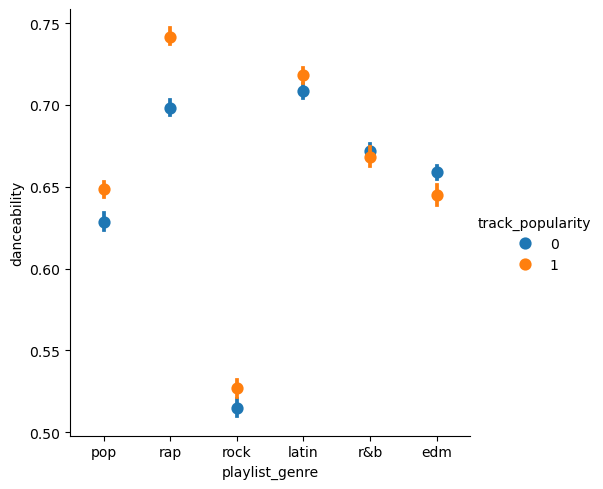

In [300]:
sns.catplot(data=spotify_df, x='playlist_genre', y='danceability', 
            hue='track_popularity', kind='point', join=False,)

plt.show()

C:\Users\abene\AppData\Local\Temp\ipykernel_6732\1231064277.py:1: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.catplot(data=spotify_df, x='playlist_genre', y='duration_ms',
C:\Users\abene\anaconda3\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


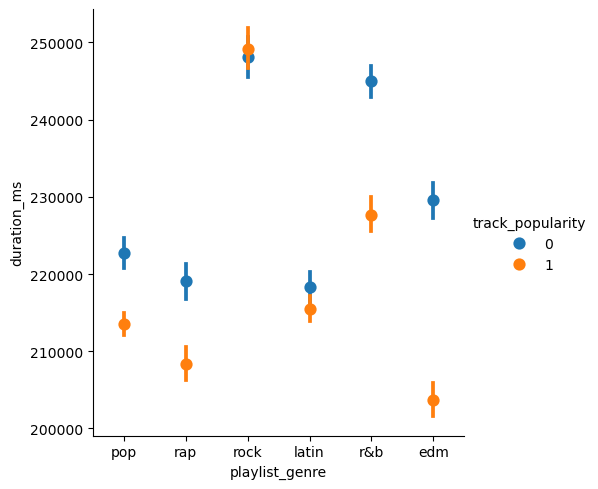

In [301]:
sns.catplot(data=spotify_df, x='playlist_genre', y='duration_ms', 
            hue='track_popularity', kind='point', join=False,)

plt.show()

C:\Users\abene\AppData\Local\Temp\ipykernel_6732\1504373791.py:1: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.catplot(data=spotify_df, x='playlist_genre', y='acousticness',
C:\Users\abene\anaconda3\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


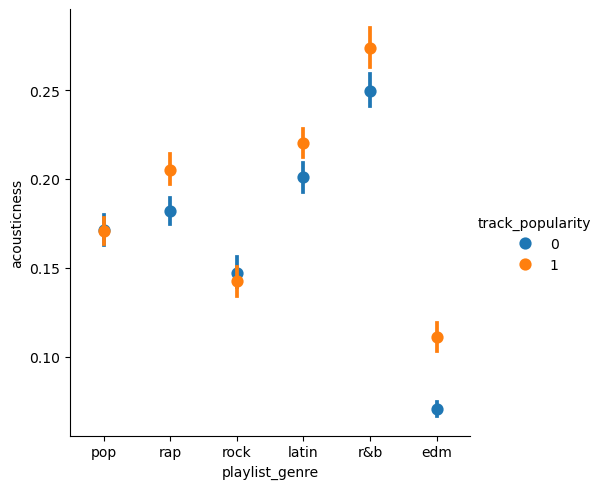

In [302]:
sns.catplot(data=spotify_df, x='playlist_genre', y='acousticness', 
            hue='track_popularity', kind='point', join=False)

plt.show()

C:\Users\abene\AppData\Local\Temp\ipykernel_6732\1854207163.py:1: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.catplot(data=spotify_df, x='playlist_genre', y='instrumentalness',
C:\Users\abene\anaconda3\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


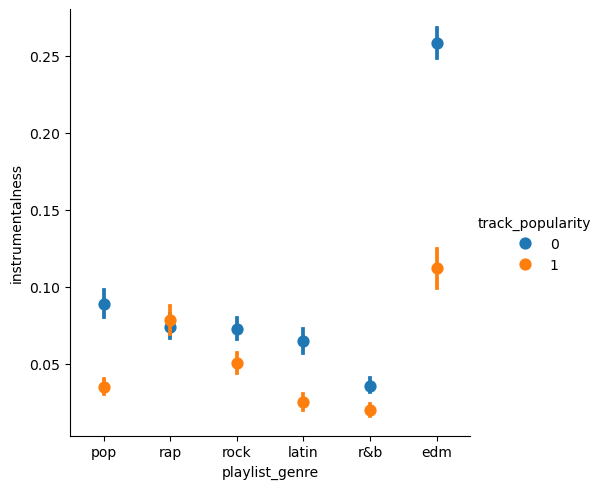

In [303]:
sns.catplot(data=spotify_df, x='playlist_genre', y='instrumentalness', 
            hue='track_popularity', kind='point', join=False)

plt.show()

C:\Users\abene\AppData\Local\Temp\ipykernel_6732\3716556794.py:1: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.catplot(data=spotify_df, x='playlist_genre', y='loudness',
C:\Users\abene\anaconda3\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


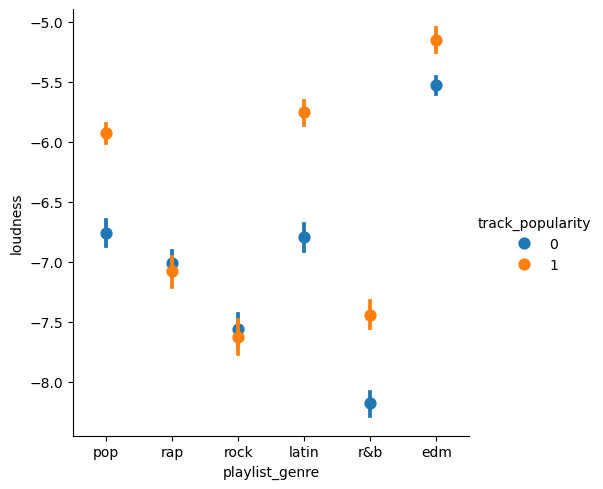

In [304]:
sns.catplot(data=spotify_df, x='playlist_genre', y='loudness', 
            hue='track_popularity', kind='point', join=False)

plt.show()

C:\Users\abene\AppData\Local\Temp\ipykernel_6732\4142533677.py:1: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.catplot(data=spotify_df, x='playlist_genre', y='energy',
C:\Users\abene\anaconda3\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


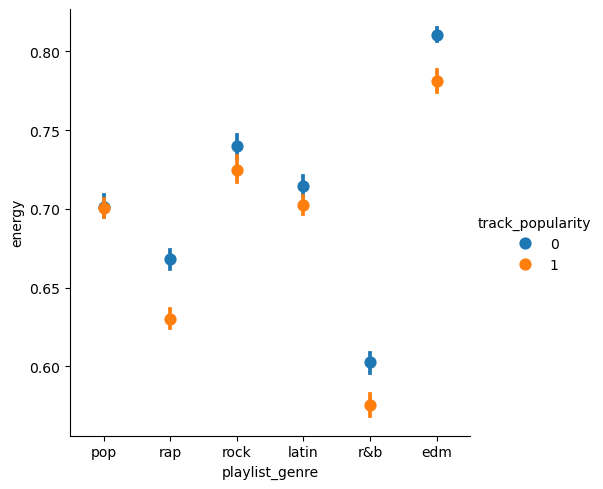

In [305]:
sns.catplot(data=spotify_df, x='playlist_genre', y='energy', 
            hue='track_popularity', kind='point', join=False)

plt.show()

C:\Users\abene\AppData\Local\Temp\ipykernel_6732\1616900556.py:1: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.catplot(data=spotify_df, x='playlist_genre', y='valence',
C:\Users\abene\anaconda3\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


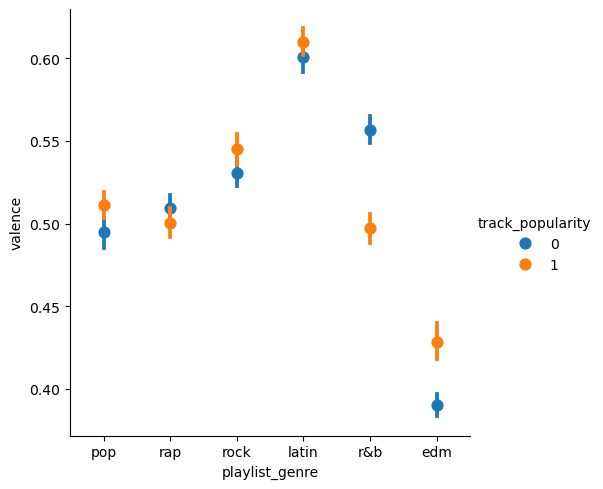

In [306]:
sns.catplot(data=spotify_df, x='playlist_genre', y='valence', 
            hue='track_popularity', kind='point', join=False)

plt.show()

## C. Cluster Analysis

I'm going to conduct my cluster using **continuous inputs.**

In [307]:
from sklearn.cluster import KMeans

In [308]:
from sklearn.preprocessing import StandardScaler

#### From my display of the categorical counts at the onset of this notebook, I found that there were 5 missing variables in the dataset. I opted to keep them in for the exploration of the data, but I'm dropping them now for the clustering. 

As a result of this drop, I've lost 5 rows from my original data frame.

In [309]:
spotify_df_clean = spotify_df.dropna().copy()

In [310]:
spotify_df_clean.isna().sum()

track_id                    0
track_name                  0
track_artist                0
track_popularity            0
track_album_id              0
track_album_name            0
track_album_release_date    0
playlist_name               0
playlist_id                 0
playlist_genre              0
playlist_subgenre           0
danceability                0
energy                      0
key                         0
loudness                    0
mode                        0
speechiness                 0
acousticness                0
instrumentalness            0
liveness                    0
valence                     0
tempo                       0
duration_ms                 0
dtype: int64

I'm using all 12 of my continuous input variables from the initial exploration. Since clustering is unsupervised, I want to factor in all my continuous variables into this process. However, I purposely excluded `mode` and `key` because I've been using them as categoricals.

Additionally, I'm using the inputs directly, not the summary statistics. `Valence`, `duration_ms`, `danceability`, and `loudness` are the most Gaussian looking of them, but the latter two are more skewed to the right.

The variables vary in their correlations to one another. The notable correlations are:
- Loudness and Energy: 68% positive
- Energy and Acousticness: 54% negative
- Loudness and Acousticness: 36% negative
- Danceability and Valence: 33% positive

In [311]:
spotify_features_clean = spotify_df_clean[['danceability', 'energy', 'loudness', 'speechiness', 
                                         'acousticness', 'instrumentalness', 'liveness', 'valence', 
                                         'tempo', 'duration_ms']].copy()

In [312]:
X = StandardScaler().fit_transform(spotify_features_clean)

In [313]:
spotify_features_clean.shape

(32828, 10)

In [314]:
X.shape

(32828, 10)

C:\Users\abene\anaconda3\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


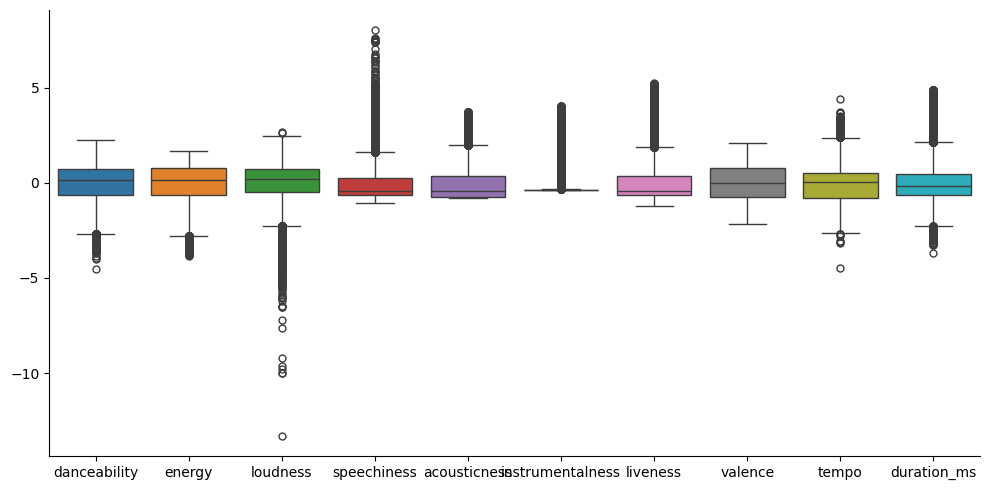

In [315]:
sns.catplot(data=pd.DataFrame(X, columns=spotify_features_clean.columns), kind='box', aspect=2)

plt.show()

In [316]:
spotify_df_clean_copy = spotify_df_clean.copy()

#### My next step is to prepare a knee chart to find the ideal number of clusters that I should be using for this dataset.

In [317]:
tots_within = []



for k in range(1, 35):
    km = KMeans(n_clusters=k, random_state=130, n_init=25, max_iter=500)
    km = km.fit(X)
    
    tots_within.append(km.inertia_)

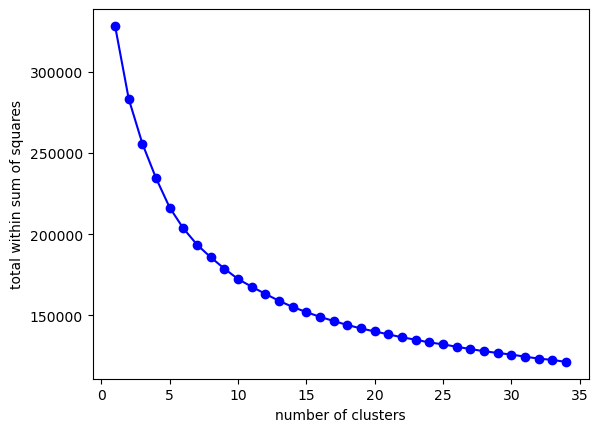

In [318]:
fig, ax = plt.subplots()

ax.plot(range(1, 35), tots_within, 'bo-')
ax.set_xlabel('number of clusters')
ax.set_ylabel('total within sum of squares')

plt.show()

### In my full EDA, I experimented with 2 clusters and 6 clusters (the number of playlist genres) but they didn't provide me with the results I wanted, so I selected 10 as the optimal number of clusters with what I consider to be the clearest knee-bend.

In [319]:
clusters_10 = KMeans(n_clusters=10, random_state=130, n_init=25, max_iter=500).fit_predict(X)

In [320]:
spotify_df_clean_copy['k10'] = pd.Series(clusters_10, index=spotify_df_clean_copy.index).astype('category')

C:\Users\abene\anaconda3\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


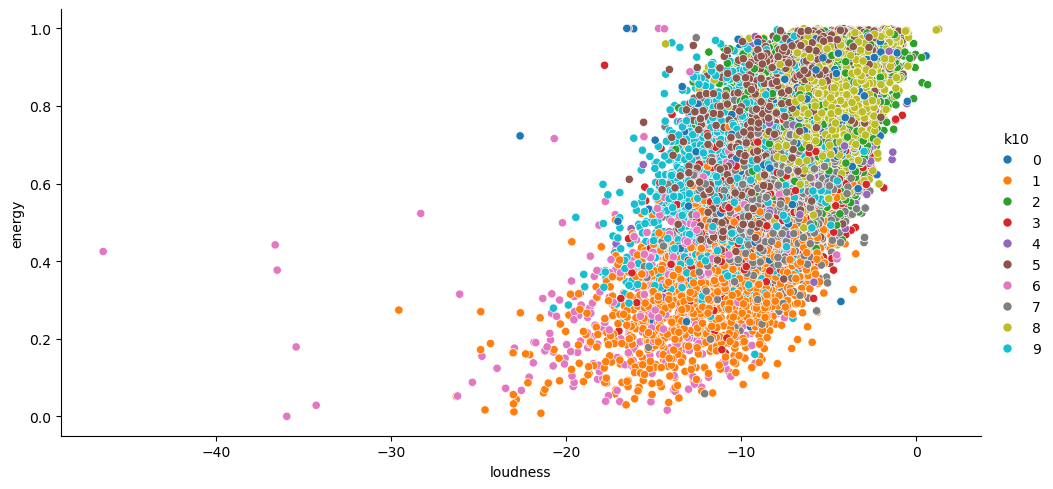

In [321]:
sns.relplot(data=spotify_df_clean_copy, x='loudness', y='energy', 
            hue='k10', aspect=2)

plt.show()

C:\Users\abene\anaconda3\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


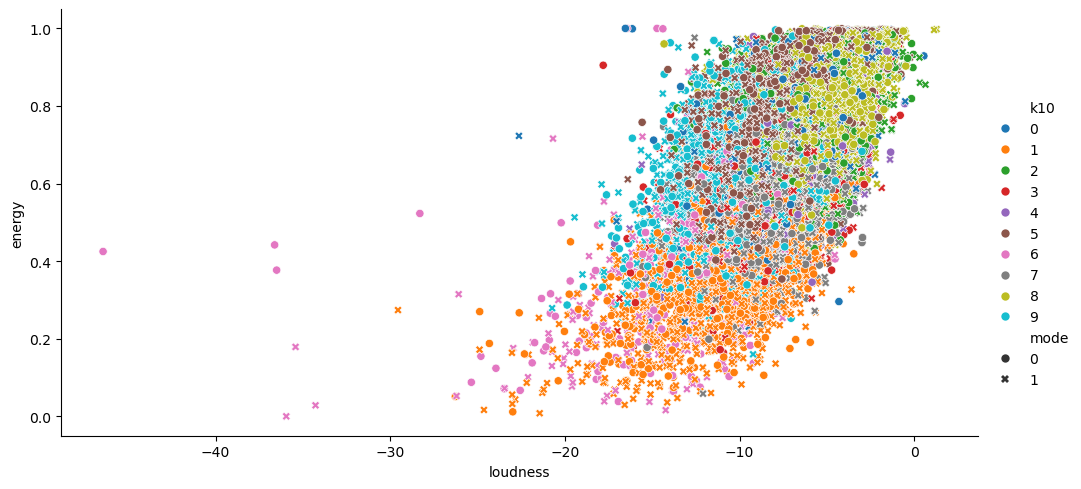

In [322]:
sns.relplot(data=spotify_df_clean_copy, x='loudness', y='energy', 
            hue='k10', style='mode', aspect=2)

plt.show()

C:\Users\abene\anaconda3\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


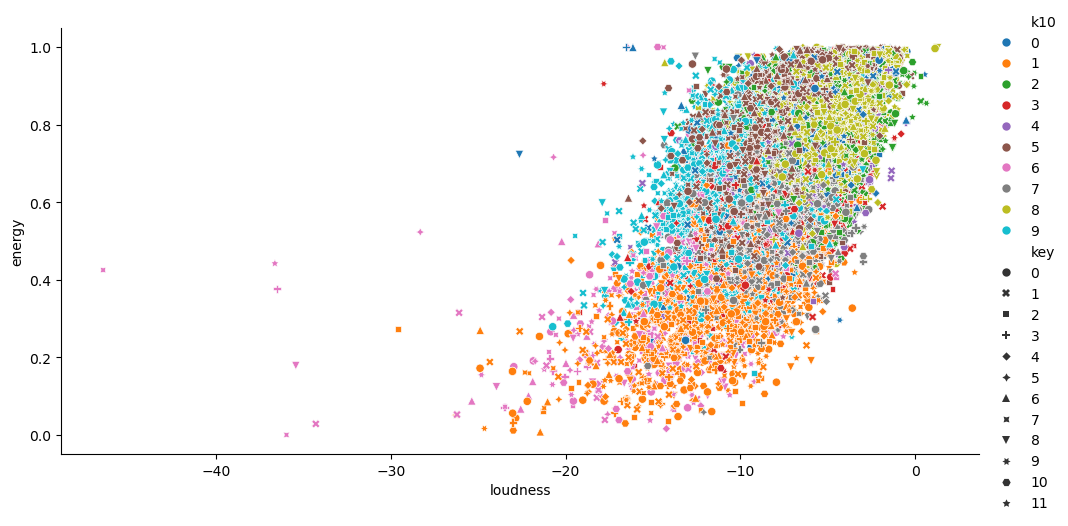

In [323]:
sns.relplot(data=spotify_df_clean_copy, x='loudness', y='energy', 
            hue='k10', style='key', aspect=2)

plt.show()

C:\Users\abene\anaconda3\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


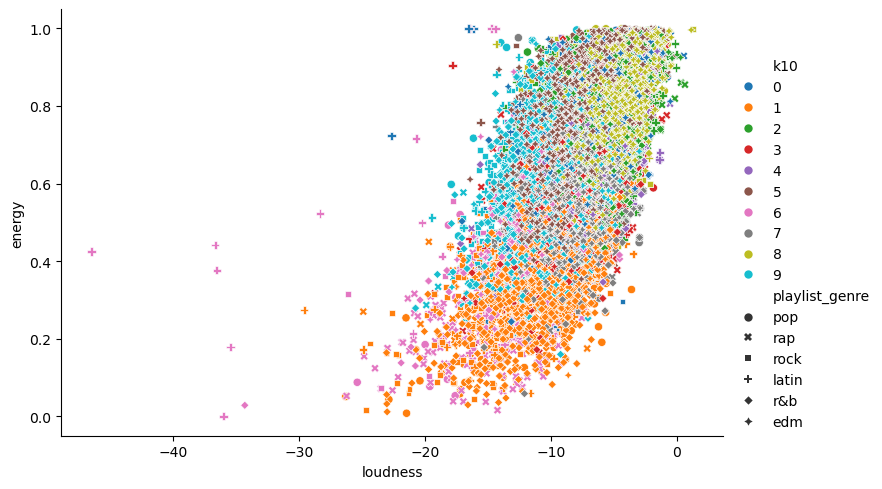

In [324]:
sns.relplot(data=spotify_df_clean_copy, x='loudness', y='energy', 
            hue='k10', style='playlist_genre', aspect=1.5)

plt.show()

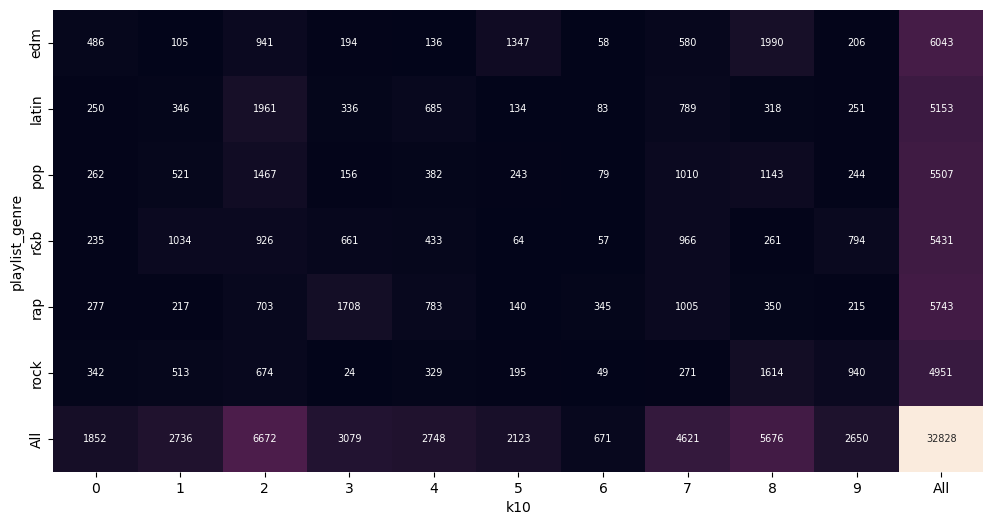

In [325]:
fig, ax = plt.subplots(figsize = (12, 6))

sns.heatmap(data = pd.crosstab( spotify_df_clean_copy.playlist_genre, spotify_df_clean_copy.k10, margins=True ), 
            annot=True, annot_kws={"fontsize": 7}, fmt='g',
            cbar=False,
            ax=ax)

plt.show()

This heatmap, like the scatterplots above, show that this dataset is quite difficult to cleanly capture in clusters. This is exemplified by the fact that no genre has more than half of its values accurately captured in a single cluster. However, some clusters were better able to correctly capture values (and playlist genres) than others. For example, over half of the values captured in cluster 6 come from the rap genre, and the same is true for cluster 5 and the edm genre.

In my project proposal, I was concerned with whether I was missing a trick because I couldn't get my clusters to wholly capture the unique categories in the data like we saw in different lecture examples throughout the semester. However, now, I'm more willing to say that this is quite a different data set from some of those lecture examples. This data set is messier, less structured, and less tailored for clean clusters. I imagine many real-world data science projects will have results similar to these.

## Examining and cleaning data before modeling

Before fitting and interpreting models, I wanted to explore any duplicate tracks in the data set and whether or not they impact the output. My full EDA shows the full exploration I did to discover that there were 1687 tracks that were being repeated in multiple playlist genres. This is significant because `playlist_genre` is one of my inputs and the features in my modeling process could be muddied if I let these duplicate values remain in my data set.

I'm showing an abridged version of this discovery below, as well as how I opted to solve it.

In [326]:
spotify_df.track_id

0        6f807x0ima9a1j3VPbc7VN
1        0r7CVbZTWZgbTCYdfa2P31
2        1z1Hg7Vb0AhHDiEmnDE79l
3        75FpbthrwQmzHlBJLuGdC7
4        1e8PAfcKUYoKkxPhrHqw4x
                  ...          
32828    7bxnKAamR3snQ1VGLuVfC1
32829    5Aevni09Em4575077nkWHz
32830    7ImMqPP3Q1yfUHvsdn7wEo
32831    2m69mhnfQ1Oq6lGtXuYhgX
32832    29zWqhca3zt5NsckZqDf6c
Name: track_id, Length: 32833, dtype: object

In [327]:
spotify_df.groupby(['track_id']).\
aggregate(num_track_pop_values = ('track_popularity', 'nunique'),
          num_playlist_genre_values = ('playlist_genre', 'nunique'))

,num_track_pop_values,num_playlist_genre_values
track_id,,
0017A6SJgTbfQVU2EtsPNo,1,1
002xjHwzEx66OWFV2IP9dk,1,1
004s3t0ONYlzxII9PLgU6z,1,1
008MceT31RotUANsKuzy3L,1,1
008rk8F6ZxspZT4bUlkIQG,1,1
...,...,...
7zxRMhXxJMQCeDDg0rKAVo,1,1
7zyLObYw4QUKQDyZOb4J0Y,1,1
7zycSpvjDcqh6YT1FEl2kY,1,1


In [328]:
spotify_df.groupby(['track_id']).\
aggregate(num_track_pop_values = ('track_popularity', 'nunique'),
          num_playlist_genre_values = ('playlist_genre', 'nunique')).\
nunique()

num_track_pop_values         1
num_playlist_genre_values    5
dtype: int64

### This is now where I'm assigning the grouped dataframe to a new object and beginning the process of removing the repeated tracks from a new, cleaned dataframe.

In [329]:
track_grouped_by_genre = spotify_df.groupby(['track_id']).\
aggregate(num_track_pop_values = ('track_popularity', 'nunique'),
          num_playlist_genre_values = ('playlist_genre', 'nunique'))

In [330]:
repeated_track_df = track_grouped_by_genre.loc[track_grouped_by_genre.num_playlist_genre_values > 1].reset_index()

In [331]:
track_list = []

for n in range(len(repeated_track_df)):
    track_list.append(repeated_track_df.track_id[n])

In [332]:
'''
I'm creating an 'initial' dataframe to host the non-manipulated version of this dataframe. 

I don't expect to use it again but want to have the insurance.

'''
cleaned_df_initial = spotify_df_clean.copy()

In [333]:
cleaned_df = cleaned_df_initial.copy()

In [334]:
for track in track_list:
    repeated_values_to_drop = cleaned_df.loc[cleaned_df.track_id == track].index
    cleaned_df = cleaned_df.drop(repeated_values_to_drop).copy()

### Below, I'm showing that my cleaned dataframe has removed all of the repeated track_id values

In [335]:
cleaned_df.loc[cleaned_df['track_id'].isin(track_list)]

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms


### This process forced me to remove over 4000 rows and 1687 unique track_id values. While this is not ideal, I prefer this outcome compared to the alternative of having 1687 tracks and their various features showing up in multiple playlist genres.

## D. Models: Fitting and Interpretation

In [336]:
import statsmodels.formula.api as smf 

In [337]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

In [338]:
from patsy import dmatrices
from sklearn.model_selection import cross_val_score

In [339]:
from patsy import dmatrix

In [340]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [341]:
from sklearn.model_selection import StratifiedKFold

In [342]:
from sklearn.metrics import roc_curve

### My earlier exploration revealed that the following continuous inputs have non Gaussian-like distributions:

- Energy
- Speechiness
- Acousticness
- Instrumentalness
- Liveness
- Tempo

Therefore, I'm applying the natural log transformation to all of them, adding in a slight buffer in case they have any values of 0.

In [343]:
non_gauss_inputs = ['energy', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'tempo']

In [344]:
cleaned_df_copy = cleaned_df.copy()

In [345]:
for n in non_gauss_inputs:
    cleaned_df_copy[n] = np.where(cleaned_df_copy[n] <= 0, 0.01, cleaned_df_copy[n])

In [346]:
for input in range(len(non_gauss_inputs)):
    cleaned_df_copy[non_gauss_inputs[input]] = np.log(cleaned_df_copy[non_gauss_inputs[input]])

### As seen below, my continuous inputs have vastly different scales. Therefore, I'm going to standardize them.

In [347]:
continuous_inputs = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 
                                    'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']

C:\Users\abene\anaconda3\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


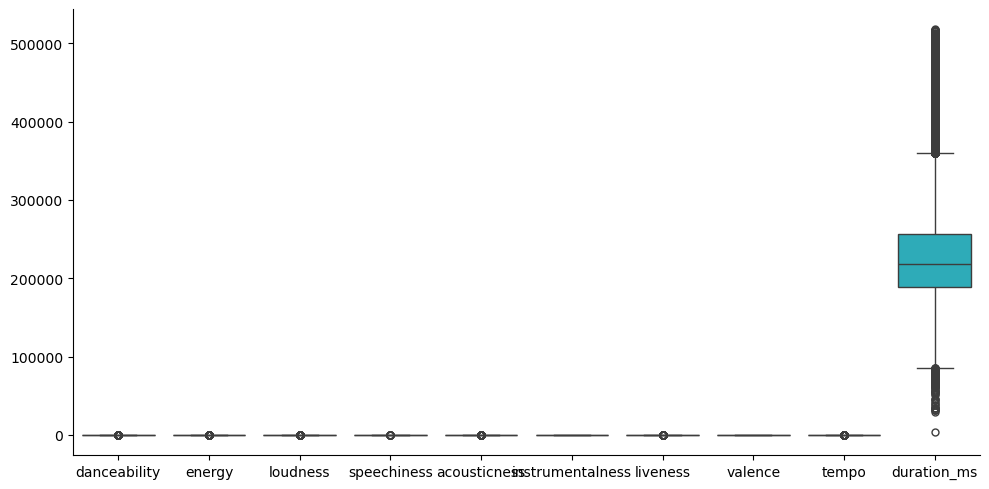

In [348]:
sns.catplot(data=cleaned_df_copy[continuous_inputs], 
            kind='box', aspect=2)

plt.show()

In [349]:
cleaned_df_copy[continuous_inputs] = StandardScaler().fit_transform(cleaned_df_copy[continuous_inputs])

### Below is the standardized version of these inputs.

C:\Users\abene\anaconda3\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


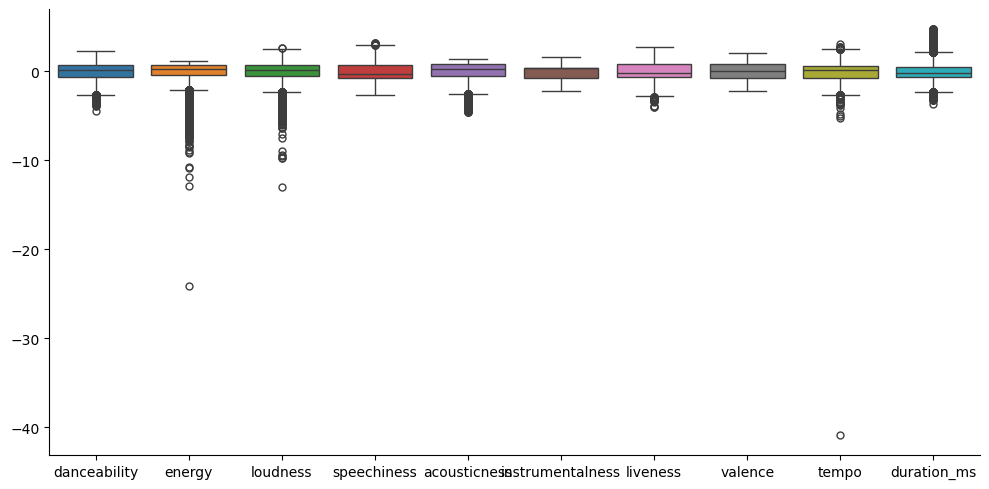

In [350]:
sns.catplot(data=cleaned_df_copy[continuous_inputs], 
            kind='box', aspect=2)

plt.show()

### Now, I'm starting the process of fitting my models. 

In order to make my formulas easier to read, I will be creating a new dataframe where my output variable is y and my input variables have values of x1, x2, etc. 

In [351]:
df_statsmodels = cleaned_df_copy.rename(columns={'track_popularity' : 'y', 'playlist_genre' : 'x1', 
                                                 'danceability': 'x2', 'energy' : 'x3', 'key' : 'x4',
                                                 'loudness' : 'x5', 'mode' : 'x6', 'speechiness' : 'x7', 'acousticness' :'x8', 
                                                 'instrumentalness' : 'x9', 'liveness' : 'x10', 'valence' :'x11', 
                                                 'tempo' : 'x12', 'duration_ms' : 'x13'}).copy()

### Firstly, a model that's Intercept-only.

In [352]:
fit_intercept = smf.logit(formula='y ~ 1', data=df_statsmodels).fit()

Optimization terminated successfully.
         Current function value: 0.664970
         Iterations 4


In [353]:
# Creting a dataframe that will host predicted values for this model.
df_intercept = df_statsmodels.copy()

df_intercept['pred_probability'] = fit_intercept.predict(df_statsmodels)

In [354]:
df_intercept['pred_class'] = np.where(df_intercept.pred_probability > 0.5, 1, 0)

In [355]:
df_intercept

,track_id,track_name,track_artist,y,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,x1,...,x6,x7,x8,x9,x10,x11,x12,x13,pred_probability,pred_class
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,1,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,0.363314,-0.208287,-1.592437,0.456465,-0.995400,0.140780,-0.950243,0.381866,0
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,1,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-0.984645,0.250035,0.341484,-0.836171,0.909848,0.212367,-0.626047,0.381866,0
6,2OAylPUDDfwRGfe0lYqlCQ,Never Really Over - R3HAB Remix,Katy Perry,1,7INHYSeusaFlyrHSNxm8qH,Never Really Over (R3HAB Remix),2019-07-26,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,0,-0.273094,0.626600,0.341484,0.243396,-1.526999,-0.205186,-0.648414,0.381866,0
10,3eFJI470ALf1EYjywPRsJy,Cross Me (feat. Chance the Rapper & PnB Rock) ...,Ed Sheeran,1,49bXZtlI5kQSqQMSCnSaWO,Cross Me (feat. Chance the Rapper & PnB Rock) ...,2019-06-21,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,1.103652,0.516348,-1.773043,-0.262017,1.024673,0.141781,-0.319995,0.381866,0
12,6e0CvGZf7CouOpYF8toXHC,Body On My,Loud Luxury,1,2R66I0nzp3NnuUlzIGWQ5P,Body On My,2019-03-29,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-0.656245,-0.061517,0.341484,1.331241,0.748242,0.141816,-0.569927,0.381866,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32828,7bxnKAamR3snQ1VGLuVfC1,City Of Lights - Official Radio Edit,Lush & Simon,0,2azRoBBWEEEYhqV6sb7JrT,City Of Lights (Vocal Mix),2014-04-28,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,1,0.252374,0.229022,0.341484,-1.154751,-1.280337,0.357344,-0.377155,0.381866,0
32829,5Aevni09Em4575077nkWHz,Closer - Sultan & Ned Shepard Remix,Tegan and Sara,0,6kD6KLxj7s8eCE3ABvAyf5,Closer Remixed,2013-03-08,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,1,-0.782068,-1.464665,0.105250,1.335095,-0.472308,0.352956,2.038921,0.381866,0
32830,7ImMqPP3Q1yfUHvsdn7wEo,Sweet Surrender - Radio Edit,Starkillers,0,0ltWNSY9JgxoIZO4VzuCa6,Sweet Surrender (Radio Edit),2014-04-21,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,0,-0.607012,0.382052,-2.186383,0.012702,-0.319207,0.351186,-0.283968,0.381866,0
32831,2m69mhnfQ1Oq6lGtXuYhgX,Only For You - Maor Levi Remix,Mat Zo,0,1fGrOkHnHJcStl14zNx8Jy,Only For You (Remixes),2014-01-01,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,1,0.448995,-0.781820,1.047046,1.206368,-0.863564,0.351833,2.271392,0.381866,0


In [356]:
fit_intercept.params

Intercept   -0.481637
dtype: float64

In [357]:
fit_intercept.pvalues

Intercept    0.0
dtype: float64

In [358]:
fit_intercept.conf_int().\
rename(columns={0: 'conf_lwr', 1: 'conf_upr'})

,conf_lwr,conf_upr
Intercept,-0.505613,-0.457661


#### Defining a function to plot coefficient plots for my models:

In [359]:
def my_coefplot(mod, figsize_use=(10, 4)):
    fig, ax = plt.subplots(figsize=figsize_use)
    
    ax.errorbar( y=mod.params.index,
                 x=mod.params,
                 xerr = 2 * mod.bse,
                 fmt='o', color='k', ecolor='k', elinewidth=2, ms=10)
    
    ax.axvline(x=0, linestyle='--', linewidth=3.5, color='grey')
    
    ax.set_xlabel('coefficient value')
    
    plt.show()

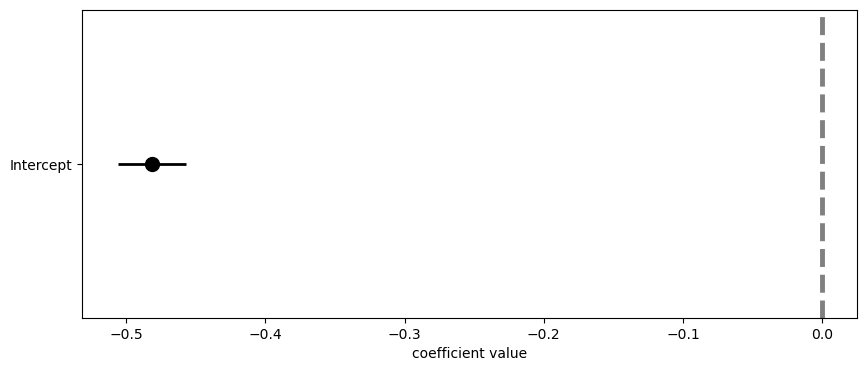

In [360]:
my_coefplot(fit_intercept)

#### - How many coefficients were estimated?
Only one, the intercept.
#### - How many coefficients (and thus features) are STATISTICALLY SIGNIFICANT using commonly accepted thresholds?
The one feature is statistically significant, a negative value.
#### - Which coefficients (and thus features) are STATISTICALLY SIGNIFICANT and what are the coefficients POSITIVE or NEGATIVE for those features?
The intercept.
#### - Which two STATISTICALLY SIGNIFICANT coefficients (and thus features) have the highest MAGNITUDE coefficient values?
N/A for this model.

#### Confusion matrix

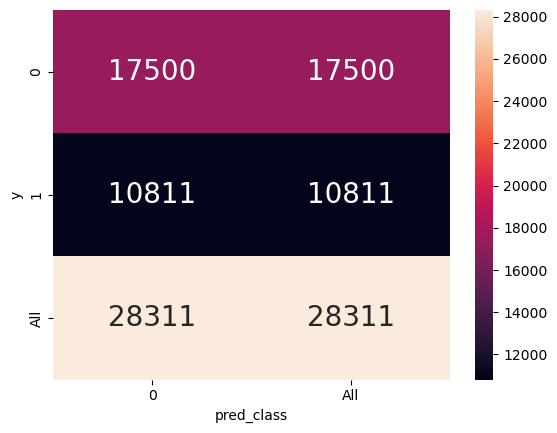

In [361]:
fig, ax = plt.subplots()

sns.heatmap( pd.crosstab( df_intercept.y, df_intercept.pred_class, margins=True ),
            annot=True, annot_kws={'size': 20}, fmt='3d')

plt.show()

In [362]:
fpr_values, tpr_values, threshold_values = roc_curve( df_intercept.y.to_numpy(), df_intercept.pred_probability.to_numpy() )

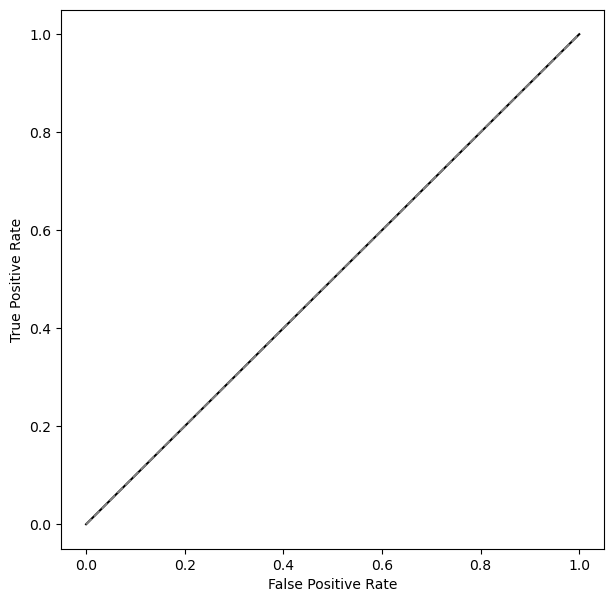

In [363]:
fig, ax = plt.subplots(figsize=(7,7))

ax.plot( fpr_values, tpr_values, color='k')
ax.plot([0, 1], [0, 1], color='grey', linestyle='--')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')

plt.show()

- Both models above show that the intercept-only formula can't correctly predict EVENTS (popular tracks). The direct slope shows that any value has just the same chance of being classified as an event or non-event, not a great model.

### Categorical inputs with additive features

In [364]:
fit_cat_add = smf.logit(formula='y ~ x1 + x4 + x6' , 
                        data=df_statsmodels).fit()

Optimization terminated successfully.
         Current function value: 0.647445
         Iterations 5


In [365]:
# Creting a dataframe that will host predicted values for this model.
df_cat_add = df_statsmodels.copy()

df_cat_add['pred_probability'] = fit_cat_add.predict(df_statsmodels)

In [366]:
df_cat_add['pred_class'] = np.where(df_cat_add.pred_probability > 0.5, 1, 0)

In [367]:
fit_cat_add.params

Intercept     -1.344072
x1[T.latin]    1.120198
x1[T.pop]      1.090257
x1[T.r&b]      0.742500
x1[T.rap]      1.009135
x1[T.rock]     1.114164
x4             0.001919
x6             0.005206
dtype: float64

In [368]:
fit_cat_add.pvalues

Intercept      1.606338e-225
x1[T.latin]    2.266422e-132
x1[T.pop]      1.266061e-124
x1[T.r&b]       1.782294e-59
x1[T.rap]      3.123114e-116
x1[T.rock]     2.608499e-135
x4              5.831478e-01
x6              8.397762e-01
dtype: float64

In [369]:
fit_cat_add.conf_int().\
rename(columns={0: 'conf_lwr', 1: 'conf_upr'})

,conf_lwr,conf_upr
Intercept,-1.426242,-1.261903
x1[T.latin],1.030520,1.209876
x1[T.pop],1.000261,1.180253
x1[T.r&b],0.653021,0.831979
x1[T.rap],0.922830,1.095439
x1[T.rock],1.025958,1.202370
x4,-0.004935,0.008774
x6,-0.045261,0.055673


#### - How many coefficients were estimated?
8 were estimated.
#### - How many coefficients (and thus features) are STATISTICALLY SIGNIFICANT using commonly accepted thresholds?
6 are statistically significant.
#### - Which coefficients (and thus features) are STATISTICALLY SIGNIFICANT and what are the coefficients POSITIVE or NEGATIVE for those features?
The input, as well as playlist genres: rock, rap, r&b, pop, and latin.
#### - Which two STATISTICALLY SIGNIFICANT coefficients (and thus features) have the highest MAGNITUDE coefficient values?
**Intercept** (absolute value of 1.34) and genre **Latin** (absolute value of 1.12).

### Continuous inputs with linear additive features


In [370]:
fit_cont_add = smf.logit(formula='y ~ x2 + x3 + x5 + x7 + x8 + x9 + x10 + x11 + x12 + x13', 
                         data=df_statsmodels).fit()

Optimization terminated successfully.
         Current function value: 0.649322
         Iterations 5


In [371]:
# Creting a dataframe that will host predicted values for this model.
df_cont_add = df_statsmodels.copy()

df_cont_add['pred_probability'] = fit_cont_add.predict(df_statsmodels)

In [372]:
df_cont_add['pred_class'] = np.where(df_cont_add.pred_probability > 0.5, 1, 0)

In [373]:
fit_cont_add.params

Intercept   -0.499165
x2          -0.019465
x3          -0.283904
x5           0.277078
x7          -0.025998
x8           0.141647
x9          -0.132736
x10         -0.018660
x11          0.095448
x12          0.040539
x13         -0.119499
dtype: float64

In [374]:
fit_cont_add.pvalues

Intercept    0.000000e+00
x2           1.693801e-01
x3           6.810269e-46
x5           4.085136e-51
x7           4.444578e-02
x8           2.989769e-21
x9           9.814711e-26
x10          1.457332e-01
x11          1.039151e-11
x12          1.812544e-03
x13          3.284550e-19
dtype: float64

In [375]:
fit_cont_add.conf_int().\
rename(columns={0: 'conf_lwr', 1: 'conf_upr'})

,conf_lwr,conf_upr
Intercept,-0.523636,-0.474693
x2,-0.047228,0.008297
x3,-0.323033,-0.244775
x5,0.240967,0.313188
x7,-0.051350,-0.000645
x8,0.112309,0.170984
x9,-0.157542,-0.107931
x10,-0.043799,0.006480
x11,0.067941,0.122955
x12,0.015067,0.066011


#### - How many coefficients were estimated?
11 were estimated.
#### - How many coefficients (and thus features) are STATISTICALLY SIGNIFICANT using commonly accepted thresholds?
8 are statistically significant.
#### - Which coefficients (and thus features) are STATISTICALLY SIGNIFICANT and what are the coefficients POSITIVE or NEGATIVE for those features?
The intercept, as well as inputs: `energy`, `loudness`, `acousticness`, `instrumentalness`, `valence`, `tempo`, `duration_ms`
#### - Which two STATISTICALLY SIGNIFICANT coefficients (and thus features) have the highest MAGNITUDE coefficient values?25
`Intercept` and `Energy`

#### Confusion matrix

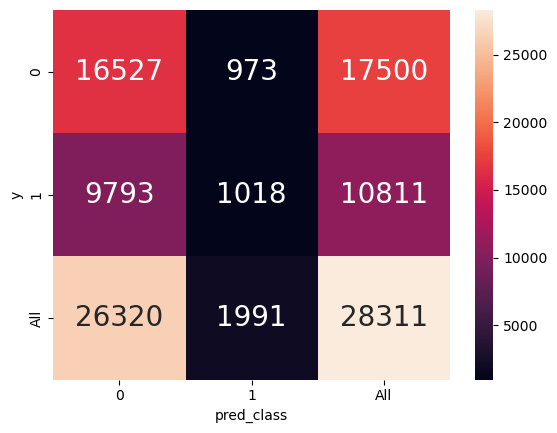

In [376]:
fig, ax = plt.subplots()

sns.heatmap( pd.crosstab( df_cont_add.y, df_cont_add.pred_class, margins=True ),
            annot=True, annot_kws={'size': 20}, fmt='3d')

plt.show()

This was the first matrix that correctly classified any events. However, 1991 out of a total of 28311 is incredibly small. That means this model still struggles to predict any probabilities > .50

### All inputs (continuous and categorical) with linear additive features.

In [377]:
fit_all_add = smf.logit(formula='y ~ x1 + x2 + x3 + x4 + x5 + x6 + x7 + x8 + x9 + x10 + x11 + x12 + x13', 
                        data=df_statsmodels).fit()

Optimization terminated successfully.
         Current function value: 0.633324
         Iterations 5


In [378]:
# Creting a dataframe that will host predicted values for this model.
df_all_add = df_statsmodels.copy()

df_all_add['pred_probability'] = fit_all_add.predict(df_statsmodels)

In [379]:
df_all_add['pred_class'] = np.where(df_all_add.pred_probability > 0.5, 1, 0)

In [380]:
fit_all_add.params

Intercept     -1.339927
x1[T.latin]    0.963619
x1[T.pop]      1.000500
x1[T.r&b]      0.656928
x1[T.rap]      0.872345
x1[T.rock]     1.384435
x2             0.097931
x3            -0.271303
x4             0.004480
x5             0.343665
x6            -0.002166
x7            -0.009909
x8             0.140774
x9            -0.084724
x10           -0.004220
x11           -0.025715
x12            0.061796
x13           -0.140105
dtype: float64

In [381]:
fit_all_add.pvalues

Intercept      6.777857e-199
x1[T.latin]     1.162604e-83
x1[T.pop]       1.105095e-94
x1[T.r&b]       6.814923e-37
x1[T.rap]       7.616283e-70
x1[T.rock]     5.274482e-155
x2              5.783333e-10
x3              1.137268e-39
x4              2.067188e-01
x5              2.150538e-72
x6              9.339160e-01
x7              4.974712e-01
x8              6.975043e-20
x9              1.028465e-10
x10             7.472891e-01
x11             8.844629e-02
x12             2.747059e-06
x13             1.004749e-23
dtype: float64

In [382]:
fit_all_add.conf_int().\
rename(columns={0: 'conf_lwr', 1: 'conf_upr'})

,conf_lwr,conf_upr
Intercept,-1.427209,-1.252646
x1[T.latin],0.866160,1.061079
x1[T.pop],0.905511,1.095488
x1[T.r&b],0.555457,0.758400
x1[T.rap],0.775564,0.969126
x1[T.rock],1.282129,1.486740
x2,0.066954,0.128908
x3,-0.311646,-0.230959
x4,-0.002474,0.011435
x5,0.306233,0.381097


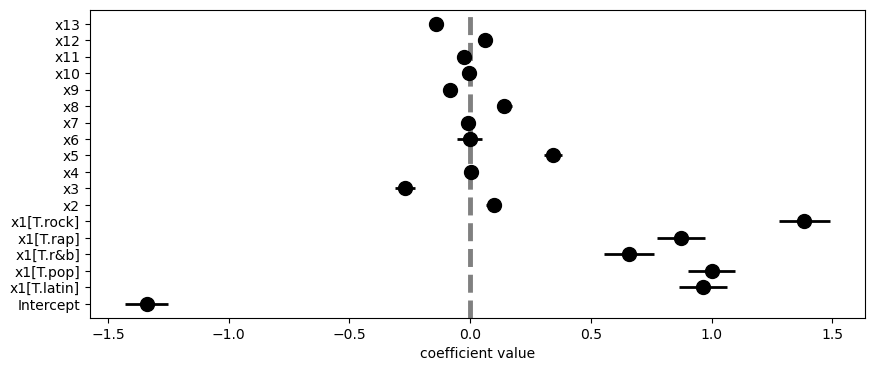

In [383]:
my_coefplot(fit_all_add)

#### - How many coefficients were estimated?
18 were estimated.
#### - How many coefficients (and thus features) are STATISTICALLY SIGNIFICANT using commonly accepted thresholds?
13 are statistically significant.
#### - Which coefficients (and thus features) are STATISTICALLY SIGNIFICANT and what are the coefficients POSITIVE or NEGATIVE for those features?
Intercept, duration_ms, tempo, instrumentalness, acousticness, loudness, energy, danceability , as well as genres: rock, rap, r&b, pop, and latin.
#### - Which two STATISTICALLY SIGNIFICANT coefficients (and thus features) have the highest MAGNITUDE coefficient values?
`Intercept` and `Rock`.

#### Confusion matrix

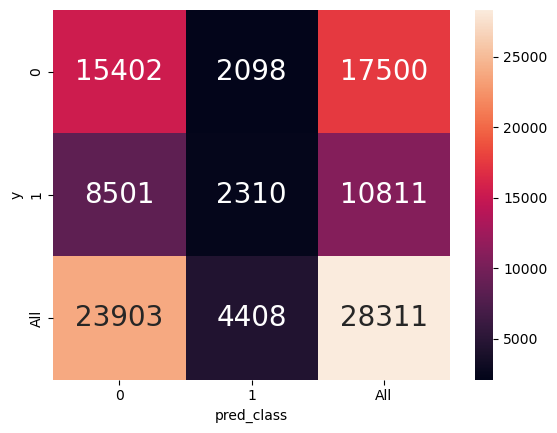

In [384]:
fig, ax = plt.subplots()

sns.heatmap( pd.crosstab( df_all_add.y, df_all_add.pred_class, margins=True ),
            annot=True, annot_kws={'size': 20}, fmt='3d')

plt.show()

In [385]:
fpr_values, tpr_values, threshold_values = roc_curve( df_all_add.y.to_numpy(), df_all_add.pred_probability.to_numpy() )

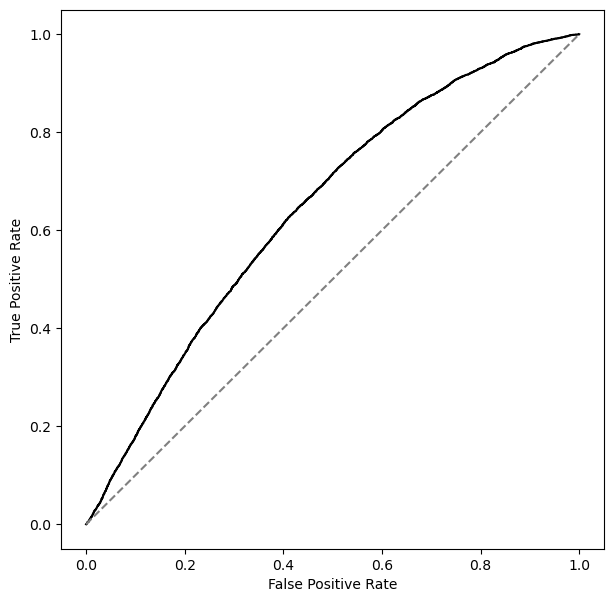

In [386]:
fig, ax = plt.subplots(figsize=(7,7))

ax.plot( fpr_values, tpr_values, color='k')
ax.plot([0, 1], [0, 1], color='grey', linestyle='--')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')

plt.show()

As seen by both the 2310 vs 2098 values in **pred_class 1** in the matrix, the ROC curve also shows that this model predicts slightly more true positives than false positives.

### Continuous inputs with linear main effect and pair-wise interactions.

In [387]:
fit_cont_pair = smf.logit(formula='y ~ x2 + x3 + x5 + x7 + x8 + x9 + x10 + x11 + x12 + x13 + (x2 + x3 + x5 + x7 + x8 + x9 + x10 + x11 + x12 + x13):(x2 + x3 + x5 + x7 + x8 + x9 + x10 + x11 + x12 + x13)',
                         data=df_statsmodels).fit()

Optimization terminated successfully.
         Current function value: 0.640963
         Iterations 6


In [388]:
# Creting a dataframe that will host predicted values for this model.
df_cont_pair = df_statsmodels.copy()

df_cont_pair['pred_probability'] = fit_cont_pair.predict(df_statsmodels)

In [389]:
df_cont_pair['pred_class'] = np.where(df_cont_pair.pred_probability > 0.5, 1, 0)

In [390]:
fit_cont_pair.params

Intercept   -0.485440
x2          -0.026161
x3          -0.355495
x5           0.300947
x7          -0.032953
x8           0.123795
x9          -0.115731
x10         -0.018068
x11          0.085643
x12          0.009807
x13         -0.115193
x2:x3       -0.047328
x2:x5        0.095191
x2:x7        0.065683
x2:x8        0.128466
x2:x9       -0.026082
x2:x10       0.021957
x2:x11       0.004284
x2:x12      -0.027925
x2:x13      -0.073881
x3:x5       -0.031088
x3:x7       -0.042794
x3:x8        0.085136
x3:x9       -0.029167
x3:x10      -0.038161
x3:x11       0.020794
x3:x12      -0.028797
x3:x13       0.003399
x5:x7        0.005859
x5:x8       -0.045094
x5:x9       -0.004773
x5:x10       0.049344
x5:x11       0.052342
x5:x12       0.007242
x5:x13      -0.022009
x7:x8       -0.030301
x7:x9       -0.008674
x7:x10      -0.011757
x7:x11      -0.047183
x7:x12       0.045300
x7:x13      -0.004152
x8:x9        0.050901
x8:x10       0.020078
x8:x11      -0.068890
x8:x12       0.020172
x8:x13    

In [391]:
fit_cont_pair.pvalues

Intercept    1.248446e-175
x2            9.074801e-02
x3            8.184658e-41
x5            1.336128e-52
x7            1.755125e-02
x8            7.488485e-13
x9            1.166933e-18
x10           1.795827e-01
x11           8.123647e-09
x12           5.328296e-01
x13           2.765952e-15
x2:x3         2.046146e-02
x2:x5         4.687800e-07
x2:x7         8.246688e-06
x2:x8         3.966551e-16
x2:x9         7.762555e-02
x2:x10        1.315604e-01
x2:x11        7.717734e-01
x2:x12        4.939632e-02
x2:x13        8.552500e-08
x3:x5         3.332579e-04
x3:x7         5.231458e-02
x3:x8         4.011083e-04
x3:x9         1.293609e-01
x3:x10        8.953782e-02
x3:x11        3.206678e-01
x3:x12        1.133368e-01
x3:x13        8.547402e-01
x5:x7         7.683757e-01
x5:x8         2.771275e-02
x5:x9         7.920458e-01
x5:x10        8.962170e-03
x5:x11        7.374298e-03
x5:x12        6.642872e-01
x5:x13        2.131133e-01
x7:x8         7.753989e-02
x7:x9         5.403494e-01
x

In [392]:
fit_cont_pair.conf_int().\
rename(columns={0: 'conf_lwr', 1: 'conf_upr'})

,conf_lwr,conf_upr
Intercept,-0.519114,-0.451766
x2,-0.056475,0.004153
x3,-0.407579,-0.303410
x5,0.262303,0.339591
x7,-0.060148,-0.005758
x8,0.089956,0.157634
x9,-0.141454,-0.090007
x10,-0.044456,0.008319
x11,0.056531,0.114755
x12,-0.021012,0.040627


#### - How many coefficients were estimated?
56 coefficients were estimated.
#### - How many coefficients (and thus features) are STATISTICALLY SIGNIFICANT using commonly accepted thresholds?
24 are statistically siginifcant.
#### - Which coefficients (and thus features) are STATISTICALLY SIGNIFICANT and what are the coefficients POSITIVE or NEGATIVE for those features?
intercept, `x3`(energy), `x5`(loudness), `x7`(speechiness), `x8`(acousticness), `x11`(valence), `x13`(duration_ms), `x2:x3`(danceability:energy), `x2:x5`(danceability:loudness), `x2:x7`(danceability:speechiness), `x2:x8`(danceability:acousticness), `x2:x12`(danceability:tempo), `x2:x13`(danceability:duration_ms), `x3:x5`(energy:loudness), `x3:x8`(energy:acousticness), `x5:x8`(loudness:acousticness), `x5:x10`(loudness:liveness), `x5:x11`(loudness:valence), `x7:x11`(speechiness:valence), `x7:x12`(speechiness:tempo), `x8:x9` (acousticness:instrumentalness), `x8:x11`(acousticness:valence), `x9:x13`(instrumentalness:duration_ms), `x10:x13`(liveness:duration_ms)
`x12:x13`(tempo:duration_ms
#### - Which two STATISTICALLY SIGNIFICANT coefficients (and thus features) have the highest MAGNITUDE coefficient values?
`Intercept` and `Energy`.

### Interact the categorical inputs with the continuous inputs

In [393]:
fit_interact = smf.logit(formula= 'y ~ (x1 + x4 + x6) * (x2 + x3 + x5 + x7 + x8 + x9 + x10 + x11 + x12 + x13)',
                         data=df_statsmodels).fit()

Optimization terminated successfully.
         Current function value: 0.623132
         Iterations 6


In [394]:
# Creting a dataframe that will host predicted values for this model.
df_fit_interact = df_statsmodels.copy()

df_fit_interact['pred_probability'] = fit_interact.predict(df_statsmodels)

In [395]:
df_fit_interact['pred_class'] = np.where(df_fit_interact.pred_probability > 0.5, 1, 0)

In [396]:
fit_interact.params

Intercept     -1.358944
x1[T.latin]    0.853210
x1[T.pop]      1.011495
x1[T.r&b]      0.733721
x1[T.rap]      0.757425
                 ...   
x6:x9         -0.014755
x6:x10         0.057835
x6:x11        -0.016499
x6:x12        -0.021279
x6:x13         0.035370
Length: 88, dtype: float64

In [397]:
fit_interact.pvalues

Intercept      7.238913e-108
x1[T.latin]     4.028334e-33
x1[T.pop]       1.746919e-50
x1[T.r&b]       1.252992e-25
x1[T.rap]       1.813068e-26
                   ...      
x6:x9           5.892641e-01
x6:x10          3.671176e-02
x6:x11          5.865530e-01
x6:x12          4.357077e-01
x6:x13          2.305294e-01
Length: 88, dtype: float64

In [398]:
fit_interact.conf_int().\
rename(columns={0: 'conf_lwr', 1: 'conf_upr'})

,conf_lwr,conf_upr
Intercept,-1.479669,-1.238220
x1[T.latin],0.713734,0.992686
x1[T.pop],0.878819,1.144171
x1[T.r&b],0.596302,0.871140
x1[T.rap],0.617986,0.896865
...,...,...
x6:x9,-0.068320,0.038810
x6:x10,0.003571,0.112099
x6:x11,-0.075959,0.042962
x6:x12,-0.074785,0.032227


In [399]:
fit_interact_df = fit_interact.conf_int().\
rename(columns={0: 'conf_lwr', 1: 'conf_upr'})

In [400]:
### Statistically significant values
len(fit_interact_df.loc[(fit_interact_df.conf_upr < 0) | (fit_interact_df.conf_lwr > 0)])

35

In [401]:
### Displaying all of the statistically significant coefficients
fit_interact_df.loc[(fit_interact_df.conf_upr < 0) | (fit_interact_df.conf_lwr > 0)].index

Index(['Intercept', 'x1[T.latin]', 'x1[T.pop]', 'x1[T.r&b]', 'x1[T.rap]',
       'x1[T.rock]', 'x2', 'x1[T.latin]:x2', 'x1[T.pop]:x2', 'x1[T.r&b]:x2',
       'x1[T.rap]:x2', 'x1[T.rock]:x2', 'x3', 'x5', 'x1[T.latin]:x5',
       'x1[T.pop]:x5', 'x1[T.rock]:x5', 'x1[T.latin]:x7', 'x1[T.pop]:x7',
       'x1[T.r&b]:x7', 'x8', 'x1[T.rock]:x8', 'x9', 'x1[T.rock]:x10',
       'x1[T.r&b]:x11', 'x1[T.rap]:x11', 'x13', 'x1[T.latin]:x13',
       'x1[T.pop]:x13', 'x1[T.r&b]:x13', 'x1[T.rap]:x13', 'x1[T.rock]:x13',
       'x4:x13', 'x6:x3', 'x6:x10'],
      dtype='object')

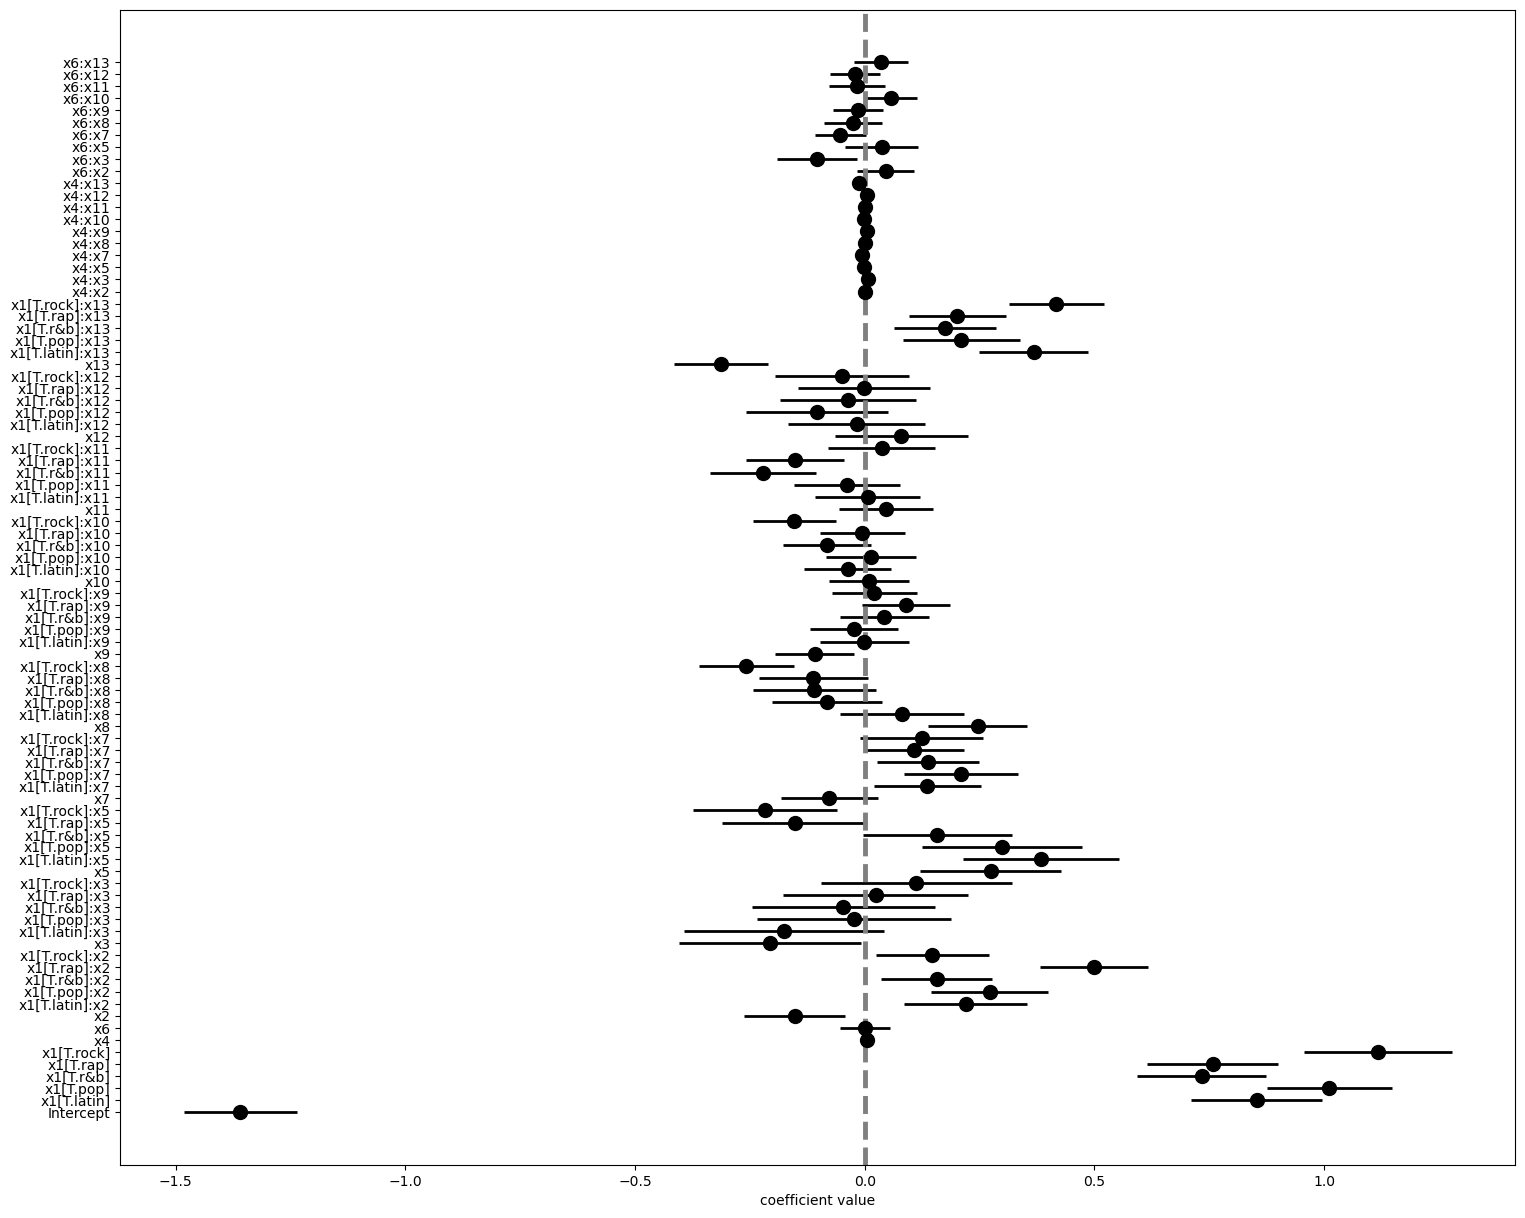

In [402]:
my_coefplot(fit_interact, (18, 15))

#### - How many coefficients were estimated?
88 were estimated.
#### - How many coefficients (and thus features) are STATISTICALLY SIGNIFICANT using commonly accepted thresholds?
35 are statistically significant
#### - Which coefficients (and thus features) are STATISTICALLY SIGNIFICANT and what are the coefficients POSITIVE or NEGATIVE for those features?
`Intercept` -1.36, `x1[T.latin]` 0.85, `x1[T.pop]` 1.01, `x1[T.r&b]` 0.73, `x1[T.rap]` 0.76, `x1[T.rock]` 1.12, `x2` -0.15, `x1[T.latin]:x2` 0.22, `x1[T.pop]:x2` 0.27, `x1[T.r&b]:x2` 0.16, `x1[T.rap]:x2` 0.50, `x1[T.rock]:x2` 0.15, `x3` -0.21, `x5` 0.27, `x1[T.latin]:x5` 0.38, `x1[T.pop]:x5` 0.30, `x1[T.rock]:x5` -0.22, `x1[T.latin]:x7` 0.14, `x1[T.pop]:x7` 0.21, `x1[T.r&b]:x7` 0.14, `x8`, `x1[T.rock]:x8` -0.26, `x9` -0.11, `x1[T.rock]:x10` -0.15, `x1[T.r&b]:x11` -0.22, `x1[T.rap]:x11` -0.15, `x13` -0.31, `x1[T.latin]:x13` 0.37, `x1[T.pop]:x13` 0.21, `x1[T.r&b]:x13` 0.17, `x1[T.rap]:x13` 0.20, `x1[T.rock]:x13` 0.42, `x4:x13` -0.01, `x6:x3` -0.10, `x6:x10` 0.06
#### - Which two STATISTICALLY SIGNIFICANT coefficients (and thus features) have the highest MAGNITUDE coefficient values?
`Intercept` and `x1[T.rock]`

#### Confusion matrix

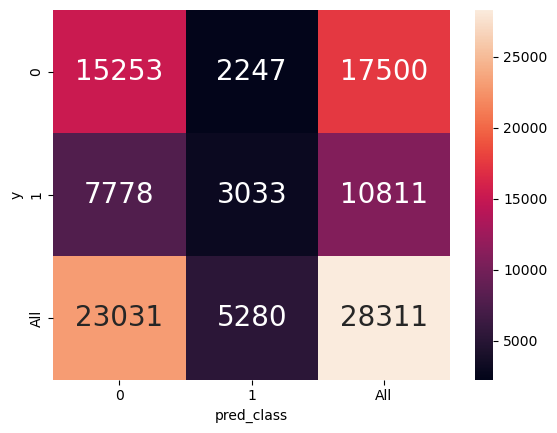

In [403]:
fig, ax = plt.subplots()

sns.heatmap( pd.crosstab( df_fit_interact.y, df_fit_interact.pred_class, margins=True ),
            annot=True, annot_kws={'size': 20}, fmt='3d')

plt.show()

In [404]:
fpr_values, tpr_values, threshold_values = roc_curve( df_fit_interact.y.to_numpy(), df_fit_interact.pred_probability.to_numpy() )

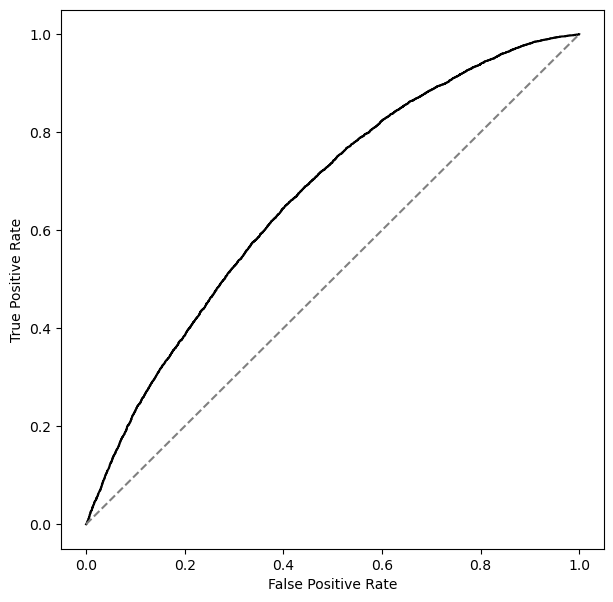

In [405]:
fig, ax = plt.subplots(figsize=(7,7))

ax.plot( fpr_values, tpr_values, color='k')
ax.plot([0, 1], [0, 1], color='grey', linestyle='--')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')

plt.show()

- This model above had the highest accuracy of them all. This is evidences by both pred_classes successfully predicting more accurate instances respectively than incorrect ones. However, the ratios still aren't fantastic. Hence, whu the accuracy doesn't climb above 65%.

### My formulation, linear additive features between playlist_genre, `x1` and continuous inputs that showed different means depending on outcome:
- danceability: `x2`
- energy: `x3`
- loudness: `x5`
- acousticness: `x8`
- instrumentalness: `x9`
- valence: `x11`
- duration_ms: `x13`

In [406]:
fit_lin_add_custom = smf.logit(formula= 'y ~ x1 + x2 + x3 + x5 + x8 + x9 + x11 + x13', data=df_statsmodels).fit()

Optimization terminated successfully.
         Current function value: 0.633750
         Iterations 5


In [407]:
# Creting a dataframe that will host predicted values for this model.
df_fit_lin_add_custom = df_statsmodels.copy()

df_fit_lin_add_custom['pred_probability'] = fit_lin_add_custom.predict(df_statsmodels)

In [408]:
df_fit_lin_add_custom['pred_class'] = np.where(df_fit_lin_add_custom.pred_probability > 0.5, 1, 0)

In [409]:
fit_lin_add_custom.params

Intercept     -1.302019
x1[T.latin]    0.947738
x1[T.pop]      0.989972
x1[T.r&b]      0.628663
x1[T.rap]      0.851269
x1[T.rock]     1.370346
x2             0.087784
x3            -0.267449
x5             0.343359
x8             0.136260
x9            -0.084968
x11           -0.022635
x13           -0.139521
dtype: float64

In [410]:
fit_lin_add_custom.pvalues

Intercept      7.336624e-278
x1[T.latin]     1.202584e-81
x1[T.pop]       1.066776e-93
x1[T.r&b]       1.128128e-34
x1[T.rap]       9.726785e-74
x1[T.rock]     1.674094e-155
x2              1.281863e-08
x3              1.652745e-39
x5              1.871048e-72
x8              7.985000e-19
x9              8.952148e-11
x11             1.332346e-01
x13             1.063065e-23
dtype: float64

In [411]:
fit_lin_add_custom.conf_int().\
rename(columns={0: 'conf_lwr', 1: 'conf_upr'})

,conf_lwr,conf_upr
Intercept,-1.373665,-1.230372
x1[T.latin],0.850681,1.044794
x1[T.pop],0.895480,1.084463
x1[T.r&b],0.528343,0.728983
x1[T.rap],0.759420,0.943117
x1[T.rock],1.269246,1.471446
x2,0.057538,0.118031
x3,-0.307305,-0.227593
x5,0.305976,0.380741
x8,0.106118,0.166402


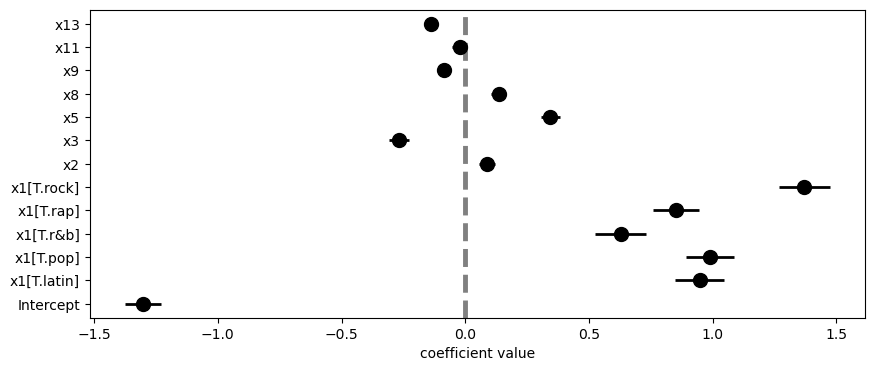

In [412]:
my_coefplot(fit_lin_add_custom)

#### - How many coefficients were estimated?
13 were estimated.
#### - How many coefficients (and thus features) are STATISTICALLY SIGNIFICANT using commonly accepted thresholds?
12 are statistically significant.
#### - Which coefficients (and thus features) are STATISTICALLY SIGNIFICANT and what are the coefficients POSITIVE or NEGATIVE for those features?
`Intercept` -1.302019, `x1[T.latin]` 0.947738, `x1[T.pop]` 0.989972, `x1[T.r&b]` 0.628663, `x1[T.rap]` 0.851269, `x1[T.rock]` 1.370346, `x2` 0.087784, `x3` -0.267449, `x5` 0.343359, `x8` 0.136260, `x9` -0.084968, `x13` -0.139521
#### - Which two STATISTICALLY SIGNIFICANT coefficients (and thus features) have the highest MAGNITUDE coefficient values?
`Intercept` and `x1[T.rock]`

### My formulation, interacting playlist_genre, `x1` with linear additive features of continuous inputs that showed different means depending on outcome:

- danceability: `x2`
- energy: `x3`
- loudness: `x5`
- acousticness: `x8`
- instrumentalness: `x9`
- valence: `x11`
- duration_ms: `x13`

In [413]:
fit_custom_int_and_add = smf.logit(formula='y ~ x1 * (x2 + x3 + x5 + x8 + x9 + x11 + x13)', data=df_statsmodels).fit()

Optimization terminated successfully.
         Current function value: 0.624852
         Iterations 6


In [414]:
# Creting a dataframe that will host predicted values for this model.
df_fit_custom_int_and_add = df_statsmodels.copy()

df_fit_custom_int_and_add['pred_probability'] = fit_custom_int_and_add.predict(df_statsmodels)

In [415]:
df_fit_custom_int_and_add['pred_class'] = np.where(df_fit_custom_int_and_add.pred_probability > 0.5, 1, 0)

In [416]:
fit_custom_int_and_add.params

Intercept         -1.287472
x1[T.latin]        0.813505
x1[T.pop]          0.931863
x1[T.r&b]          0.683124
x1[T.rap]          0.693166
x1[T.rock]         1.095063
x2                -0.160149
x1[T.latin]:x2     0.229802
x1[T.pop]:x2       0.312376
x1[T.r&b]:x2       0.184521
x1[T.rap]:x2       0.521765
x1[T.rock]:x2      0.207504
x3                -0.225984
x1[T.latin]:x3    -0.182530
x1[T.pop]:x3      -0.019422
x1[T.r&b]:x3      -0.058376
x1[T.rap]:x3       0.031294
x1[T.rock]:x3      0.066676
x5                 0.279241
x1[T.latin]:x5     0.385059
x1[T.pop]:x5       0.297761
x1[T.r&b]:x5       0.160177
x1[T.rap]:x5      -0.148856
x1[T.rock]:x5     -0.204683
x8                 0.227064
x1[T.latin]:x8     0.085280
x1[T.pop]:x8      -0.067965
x1[T.r&b]:x8      -0.117035
x1[T.rap]:x8      -0.110053
x1[T.rock]:x8     -0.263376
x9                -0.093061
x1[T.latin]:x9    -0.001969
x1[T.pop]:x9      -0.025495
x1[T.r&b]:x9       0.044362
x1[T.rap]:x9       0.084765
x1[T.rock]:x9      0

In [417]:
fit_custom_int_and_add.pvalues

Intercept          1.515038e-130
x1[T.latin]         2.097086e-32
x1[T.pop]           1.752983e-49
x1[T.r&b]           3.541662e-24
x1[T.rap]           1.478120e-27
x1[T.rock]          1.284991e-52
x2                  4.050440e-04
x1[T.latin]:x2      3.086253e-04
x1[T.pop]:x2        3.223199e-07
x1[T.r&b]:x2        1.606321e-03
x1[T.rap]:x2        3.268096e-20
x1[T.rock]:x2       4.127010e-04
x3                  1.041443e-02
x1[T.latin]:x3      8.728569e-02
x1[T.pop]:x3        8.509360e-01
x1[T.r&b]:x3        5.512237e-01
x1[T.rap]:x3        7.520638e-01
x1[T.rock]:x3       5.089887e-01
x5                  2.297274e-05
x1[T.latin]:x5      5.772918e-06
x1[T.pop]:x5        6.217912e-04
x1[T.r&b]:x5        4.730826e-02
x1[T.rap]:x5        5.715697e-02
x1[T.rock]:x5       8.726322e-03
x8                  1.392002e-07
x1[T.latin]:x8      2.056532e-01
x1[T.pop]:x8        2.514026e-01
x1[T.r&b]:x8        7.819122e-02
x1[T.rap]:x8        6.061262e-02
x1[T.rock]:x8       3.385055e-07
x9        

In [418]:
fit_custom_int_and_add.conf_int().\
rename(columns={0: 'conf_lwr', 1: 'conf_upr'})

,conf_lwr,conf_upr
Intercept,-1.391270,-1.183673
x1[T.latin],0.678978,0.948033
x1[T.pop],0.808356,1.055371
x1[T.r&b],0.551128,0.815119
x1[T.rap],0.568266,0.818066
x1[T.rock],0.954473,1.235654
x2,-0.248898,-0.071400
x1[T.latin]:x2,0.104966,0.354639
x1[T.pop]:x2,0.192561,0.432191
x1[T.r&b]:x2,0.069883,0.299159


In [419]:
fit_custom_int_and_add_conf = fit_custom_int_and_add.conf_int().\
rename(columns={0: 'conf_lwr', 1: 'conf_upr'})

In [420]:
### Number of statitsically significant coefficients.

len(fit_custom_int_and_add_conf.loc[(fit_custom_int_and_add_conf.conf_lwr > 0) | (fit_custom_int_and_add_conf.conf_upr < 0)])

29

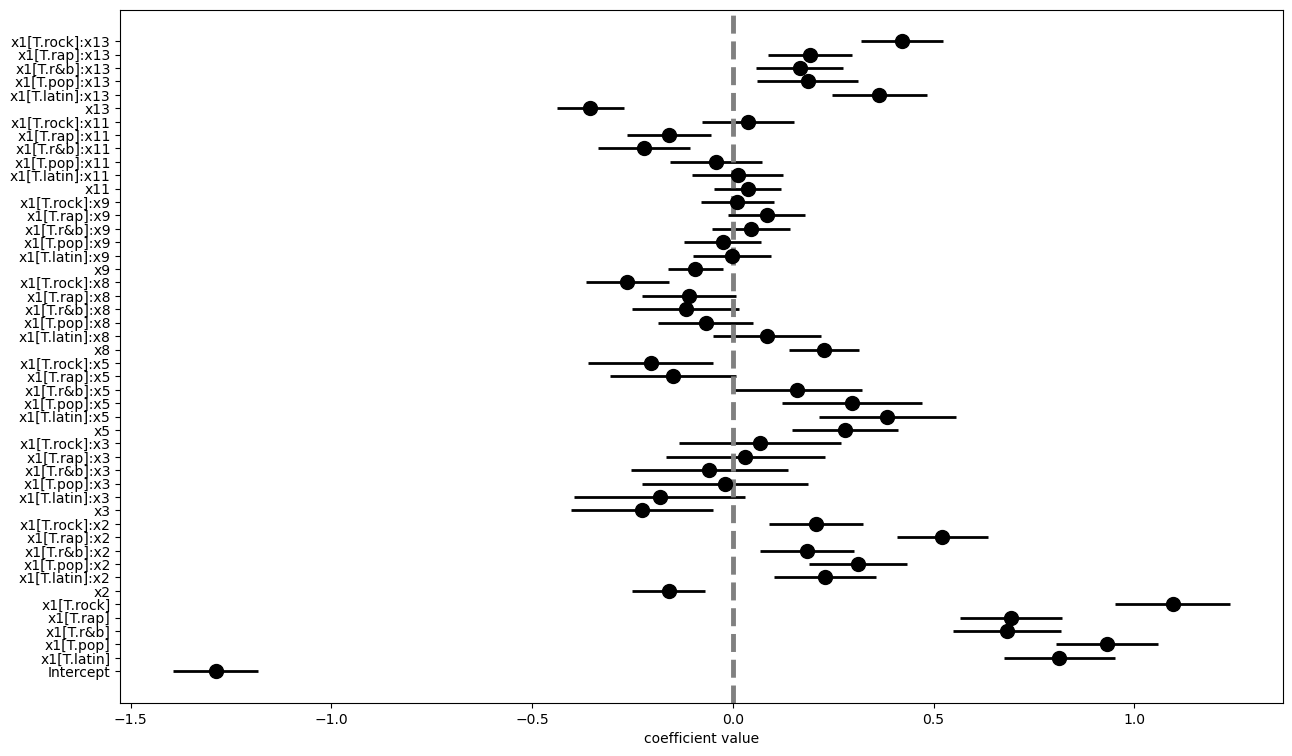

In [421]:
my_coefplot(fit_custom_int_and_add, (15, 9))

#### - How many coefficients were estimated?
48 were estimated.
#### - How many coefficients (and thus features) are STATISTICALLY SIGNIFICANT using commonly accepted thresholds?
There are 29 statistically significant coefficients.
#### - Which coefficients (and thus features) are STATISTICALLY SIGNIFICANT and what are the coefficients POSITIVE or NEGATIVE for those features?
`Intercept` -1.29 ,`x1[T.latin]` 0.81, `x1[T.pop]` 0.93, `x1[T.r&b]` 0.68, `x1[T.rap]`  0.69,
`x1[T.rock]` 1.10, `x2` -0.16, `x1[T.latin]:x2` 0.23, `x1[T.pop]:x2` 0.31, `x1[T.r&b]:x2`  0.18,
`x1[T.rap]:x2` 0.52, `x1[T.rock]:x2` 0.21, `x3` -0.23, `x5` 0.28, `x1[T.latin]:x5` 0.39,
`x1[T.pop]:x5`  0.30, `x1[T.r&b]:x5` 0.16, `x1[T.rock]:x5` -0.20, `x8` 0.23, `x1[T.rock]:x8` 0.01,
`x9` -0.09, `x1[T.r&b]:x11` -0.22, `x1[T.rap]:x11` -0.16, `x13`, `x1[T.latin]:x13` 0.36,
`x1[T.pop]:x13` 0.19, `x1[T.r&b]:x13` 0.167, `x1[T.rap]:x13` 0.19, `x1[T.rock]:x13` 0.42

#### - Which two STATISTICALLY SIGNIFICANT coefficients (and thus features) have the highest MAGNITUDE coefficient values?
`Intercept` and `x1[T.rock]` 1.10

#### Confusion matrix

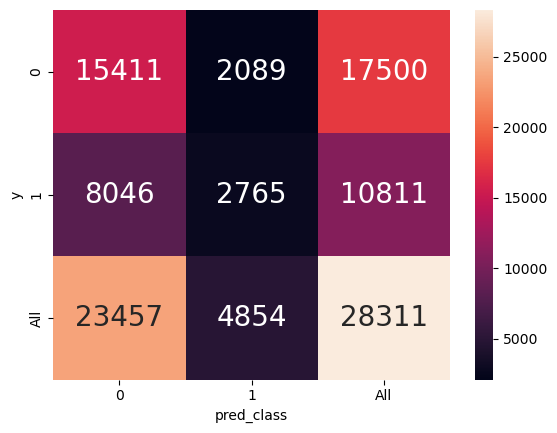

In [422]:
fig, ax = plt.subplots()

sns.heatmap( pd.crosstab( df_fit_custom_int_and_add.y, df_fit_custom_int_and_add.pred_class, margins=True ),
            annot=True, annot_kws={'size': 20}, fmt='3d')

plt.show()

In [423]:
fpr_values, tpr_values, threshold_values = roc_curve( df_fit_custom_int_and_add.y.to_numpy(), df_fit_custom_int_and_add.pred_probability.to_numpy() )

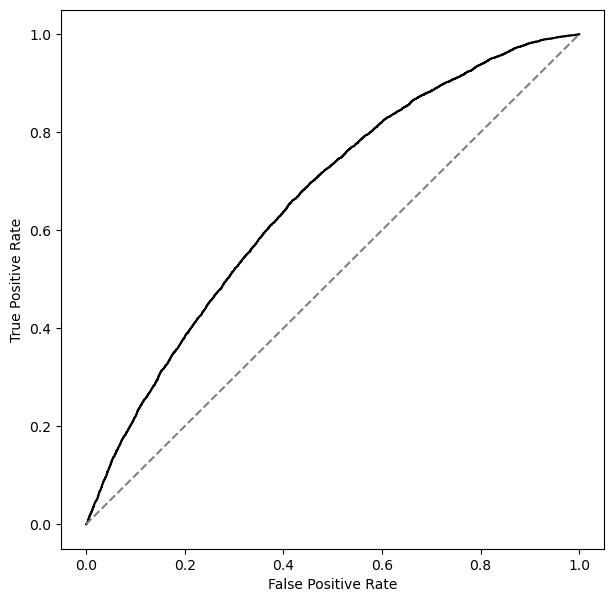

In [424]:
fig, ax = plt.subplots(figsize=(7,7))

ax.plot( fpr_values, tpr_values, color='k')
ax.plot([0, 1], [0, 1], color='grey', linestyle='--')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')

plt.show()

- This model, the custom one that I'll focus on further on this notebook, shows similar findings to the most accurate model. It has a higher count of True Positives vs False Positives and also has higher counts of True Negatives vs False Negatives. However, the ratios aren't significant enough to raise the accuracy to a significantly high percentage.

## Testing the best model
### First, I'm defining a function to fit and calculate training performance

In [425]:
### Compiling a list of all formulas I've fit at this point.

formula_list = ['y ~ 1',
                'y ~ x1 + x4 + x6',
                'y ~ x2 + x3 + x5 + x7 + x8 + x9 + x10 + x11 + x12 + x13',
                'y ~ x1 + x2 + x3 + x4 + x5 + x6 + x7 + x8 + x9 + x10 + x11 + x12 + x13',
                'y ~ x2 + x3 + x5 + x7 + x8 + x9 + x10 + x11 + x12 + x13 + (x2 + x3 + x5 + x7 + x8 + x9 + x10 + x11 + x12 + x13):(x2 + x3 + x5 + x7 + x8 + x9 + x10 + x11 + x12 + x13)',
                'y ~ (x1 + x4 + x6) * (x2 + x3 + x5 + x7 + x8 + x9 + x10 + x11 + x12 + x13)',
                'y ~ x1 + x2 + x3 + x5 + x8 + x9 + x11 + x13',
                'y ~ x1 * (x2 + x3 + x5 + x8 + x9 + x11 + x13)']

In [426]:
def fit_and_assess_logistic(mod_name, a_formula, train_data, threshold):
    a_mod = smf.logit(formula=a_formula, data=train_data).fit()
    
    train_copy = train_data.copy()
    
    train_copy['pred_probability'] = a_mod.predict( train_data )
    
    train_copy['pred_class'] = np.where( train_copy.pred_probability > threshold, 1, 0 )
    
    TN, FP, FN, TP = confusion_matrix( train_copy.y.to_numpy(), train_copy.pred_class.to_numpy() ).ravel()
    
    Accuracy = (TN + TP) / (TN + FP + FN + TP)
    
    Sensitivity = (TP) / (TP + FN)
    
    Specificity = (TN) / (TN + FP)
    
    FPR = 1 - Specificity
    
    ROC_AUC = roc_auc_score( train_copy.y.to_numpy(), train_copy.pred_probability.to_numpy() )
    
    res_dict = {'model_name': mod_name,
                'model_formula': a_formula,
                'num_coefs': len( a_mod.params ),
                'threshold': threshold,
                'Accuracy': Accuracy,
                'Sensitivity': Sensitivity,
                'Specificity': Specificity,
                'FPR': FPR,
                'ROC_AUC': ROC_AUC}
    
    return pd.DataFrame( res_dict, index=[0] )

### Testing Formula 1:

In [427]:
fit_and_assess_logistic('linear', formula_list[0], df_statsmodels, 0.5)

Optimization terminated successfully.
         Current function value: 0.664970
         Iterations 4


,model_name,model_formula,num_coefs,threshold,Accuracy,Sensitivity,Specificity,FPR,ROC_AUC
0,linear,y ~ 1,1,0.5,0.618134,0.0,1.0,0.0,0.5


### Testing Formula 2:

In [428]:
fit_and_assess_logistic('categorical_additive', formula_list[1], df_statsmodels, 0.5)

Optimization terminated successfully.
         Current function value: 0.647445
         Iterations 5


,model_name,model_formula,num_coefs,threshold,Accuracy,Sensitivity,Specificity,FPR,ROC_AUC
0,categorical_additive,y ~ x1 + x4 + x6,8,0.5,0.618134,0.0,1.0,0.0,0.592082


### Testing Formula 3:

In [429]:
fit_and_assess_logistic('continuous_additive', formula_list[2], df_statsmodels, 0.5)

Optimization terminated successfully.
         Current function value: 0.649322
         Iterations 5


,model_name,model_formula,num_coefs,threshold,Accuracy,Sensitivity,Specificity,FPR,ROC_AUC
0,continuous_additive,y ~ x2 + x3 + x5 + x7 + x8 + x9 + x10 + x11 + ...,11,0.5,0.619724,0.094163,0.9444,0.0556,0.603236


### Testing Formula 4:

In [430]:
fit_and_assess_logistic('all_additive', formula_list[3], df_statsmodels, 0.5)

Optimization terminated successfully.
         Current function value: 0.633324
         Iterations 5


,model_name,model_formula,num_coefs,threshold,Accuracy,Sensitivity,Specificity,FPR,ROC_AUC
0,all_additive,y ~ x1 + x2 + x3 + x4 + x5 + x6 + x7 + x8 + x9...,18,0.5,0.625623,0.213671,0.880114,0.119886,0.644194


### Testing Formula 5:

In [431]:
fit_and_assess_logistic('continuous_lin_+_pair', formula_list[4], df_statsmodels, 0.5)

Optimization terminated successfully.
         Current function value: 0.640963
         Iterations 6


,model_name,model_formula,num_coefs,threshold,Accuracy,Sensitivity,Specificity,FPR,ROC_AUC
0,continuous_lin_+_pair,y ~ x2 + x3 + x5 + x7 + x8 + x9 + x10 + x11 + ...,56,0.5,0.627071,0.144205,0.925371,0.074629,0.621797


### Testing Formula 6:

In [432]:
fit_and_assess_logistic('interact_cat_cont', formula_list[5], df_statsmodels, 0.5)

Optimization terminated successfully.
         Current function value: 0.623132
         Iterations 6


,model_name,model_formula,num_coefs,threshold,Accuracy,Sensitivity,Specificity,FPR,ROC_AUC
0,interact_cat_cont,y ~ (x1 + x4 + x6) * (x2 + x3 + x5 + x7 + x8 +...,88,0.5,0.645897,0.280548,0.8716,0.1284,0.667697


### Testing Formula 7:

In [433]:
fit_and_assess_logistic('add_genre_and_cont', formula_list[6], df_statsmodels, 0.5)

Optimization terminated successfully.
         Current function value: 0.633750
         Iterations 5


,model_name,model_formula,num_coefs,threshold,Accuracy,Sensitivity,Specificity,FPR,ROC_AUC
0,add_genre_and_cont,y ~ x1 + x2 + x3 + x5 + x8 + x9 + x11 + x13,13,0.5,0.625481,0.210526,0.881829,0.118171,0.642818


### Testing Formula 8:

In [434]:
fit_and_assess_logistic('interact_genre_and_cont_add', formula_list[7], df_statsmodels, 0.5)

Optimization terminated successfully.
         Current function value: 0.624852
         Iterations 6


,model_name,model_formula,num_coefs,threshold,Accuracy,Sensitivity,Specificity,FPR,ROC_AUC
0,interact_genre_and_cont_add,y ~ x1 * (x2 + x3 + x5 + x8 + x9 + x11 + x13),48,0.5,0.642012,0.255758,0.880629,0.119371,0.663834


### Which model has the best performance?

#### Highest Accuracy:
The model with the highest accuracy is the interaction between the categorical and continuous variables, with an accuracy of **64.6%**

#### Highest ROC AUC:
The model with the highest ROC AUC is the interaction between the categorical and continuous variables, with an ROC AUC of **66.87%**. So, the ROC AUC score for the best model is HIGHER than the Accuracy. 
#### How many coefficients in the best model:
The model has 88 coefficients.

## E. Models: Predictions

### The two models that I'll be making predictions with are `all_additive` and `interact_cat_cont`.

#### Predicting `all_additive`:

The three most important inputs based on their statistical significance are:
- `x1` (playlist_genre)
- `x3` (energy)
- `x5` (loudness): most significant continuous input

In [435]:
input_grid = pd.DataFrame([(x1, x2, x3, x4, x5, x6, x7, x8, x9, x10, x11, x12, x13) for x1 in df_statsmodels.x1.unique()
                          for x2 in [df_statsmodels.x2.mean()]
                           for x3 in np.linspace(df_statsmodels.x3.min(), df_statsmodels.x3.max(), num=5)
                           for x4 in df_statsmodels.x4.unique()
                           for x5 in np.linspace(df_statsmodels.x5.min(), df_statsmodels.x5.max(), num=101)
                           for x6 in df_statsmodels.x6.unique()
                           for x7 in [df_statsmodels.x7.mean()]
                           for x8 in [df_statsmodels.x8.mean()]
                           for x9 in [df_statsmodels.x9.mean()]
                           for x10 in [df_statsmodels.x10.mean()]
                           for x11 in [df_statsmodels.x11.mean()]
                           for x12 in [df_statsmodels.x12.mean()]
                           for x13 in [df_statsmodels.x13.mean()]],
                          columns = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13'])

In [436]:
df_viz = input_grid.copy()

### Predicting the additive model with all inputs

In [437]:
df_viz['pred_probability_all_add'] = fit_all_add.predict(input_grid)

In [438]:
df_viz

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,pred_probability_all_add
0,pop,2.268838e-16,-24.170536,7,-12.982297,1,-2.891262e-16,-1.606257e-17,-1.204693e-16,2.369229e-16,3.533765e-16,2.706543e-15,-7.228155e-17,0.856405
1,pop,2.268838e-16,-24.170536,7,-12.982297,0,-2.891262e-16,-1.606257e-17,-1.204693e-16,2.369229e-16,3.533765e-16,2.706543e-15,-7.228155e-17,0.856671
2,pop,2.268838e-16,-24.170536,7,-12.825938,1,-2.891262e-16,-1.606257e-17,-1.204693e-16,2.369229e-16,3.533765e-16,2.706543e-15,-7.228155e-17,0.862887
3,pop,2.268838e-16,-24.170536,7,-12.825938,0,-2.891262e-16,-1.606257e-17,-1.204693e-16,2.369229e-16,3.533765e-16,2.706543e-15,-7.228155e-17,0.863143
4,pop,2.268838e-16,-24.170536,7,-12.669579,1,-2.891262e-16,-1.606257e-17,-1.204693e-16,2.369229e-16,3.533765e-16,2.706543e-15,-7.228155e-17,0.869122
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72715,edm,2.268838e-16,1.176590,8,2.340881,0,-2.891262e-16,-1.606257e-17,-1.204693e-16,2.369229e-16,3.533765e-16,2.706543e-15,-7.228155e-17,0.306014
72716,edm,2.268838e-16,1.176590,8,2.497240,1,-2.891262e-16,-1.606257e-17,-1.204693e-16,2.369229e-16,3.533765e-16,2.706543e-15,-7.228155e-17,0.317074
72717,edm,2.268838e-16,1.176590,8,2.497240,0,-2.891262e-16,-1.606257e-17,-1.204693e-16,2.369229e-16,3.533765e-16,2.706543e-15,-7.228155e-17,0.317543
72718,edm,2.268838e-16,1.176590,8,2.653599,1,-2.891262e-16,-1.606257e-17,-1.204693e-16,2.369229e-16,3.533765e-16,2.706543e-15,-7.228155e-17,0.328822


The plot below shows that the trends for `x5` - loudness, share similar shapes when grouped by `playlist_genre` but that they change quite signifcantly when grouped by `x3` - energy. For the most part, all plots show that higher values of **loudness** correlate with higher prediction probabilities. Interestingly, it's the lower values for **energy** that correlate with higher prediction probabilities. In other words, when `x5` is high and `x3` is low, prediction probability TENDS to be higher.

C:\Users\abene\anaconda3\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


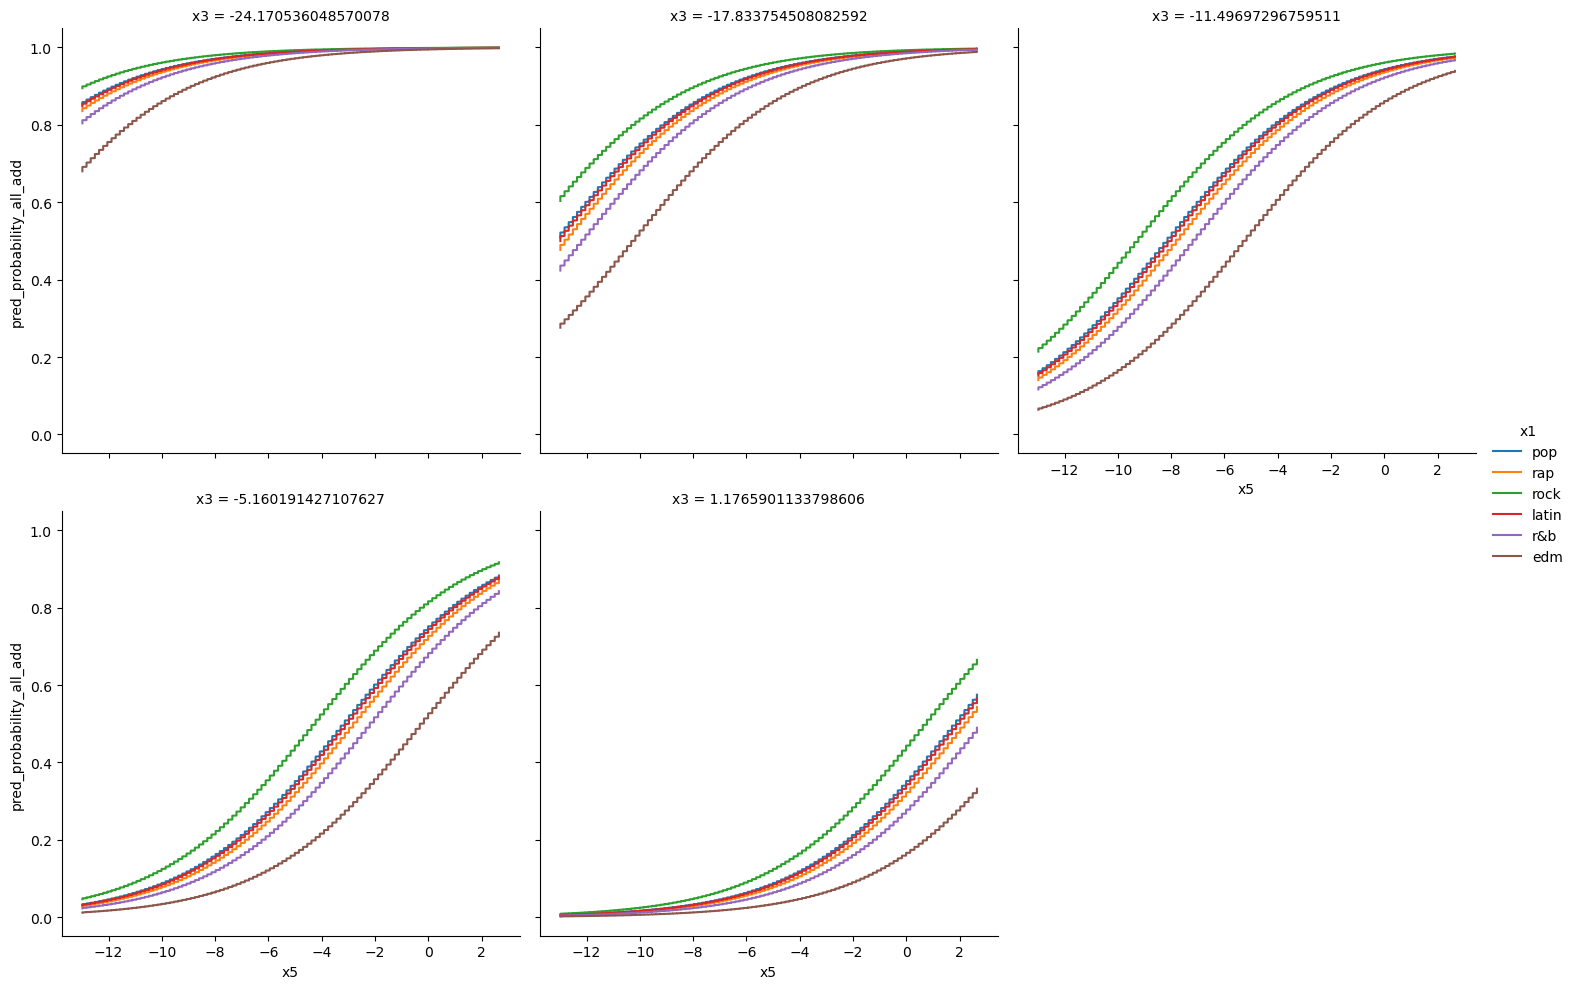

In [439]:
sns.relplot(data = df_viz, x='x5', y='pred_probability_all_add', hue='x1', col='x3',
            kind='line', estimator=None, units='x1',
            col_wrap=3)

plt.show()

### Predicting the most accurate model, `interact_cat_cont`

In [440]:
df_viz['pred_probability_int_cat_cont'] = fit_interact.predict(input_grid)

In [441]:
df_viz

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,pred_probability_all_add,pred_probability_int_cat_cont
0,pop,2.268838e-16,-24.170536,7,-12.982297,1,-2.891262e-16,-1.606257e-17,-1.204693e-16,2.369229e-16,3.533765e-16,2.706543e-15,-7.228155e-17,0.856405,0.264636
1,pop,2.268838e-16,-24.170536,7,-12.982297,0,-2.891262e-16,-1.606257e-17,-1.204693e-16,2.369229e-16,3.533765e-16,2.706543e-15,-7.228155e-17,0.856671,0.045235
2,pop,2.268838e-16,-24.170536,7,-12.825938,1,-2.891262e-16,-1.606257e-17,-1.204693e-16,2.369229e-16,3.533765e-16,2.706543e-15,-7.228155e-17,0.862887,0.282993
3,pop,2.268838e-16,-24.170536,7,-12.825938,0,-2.891262e-16,-1.606257e-17,-1.204693e-16,2.369229e-16,3.533765e-16,2.706543e-15,-7.228155e-17,0.863143,0.049126
4,pop,2.268838e-16,-24.170536,7,-12.669579,1,-2.891262e-16,-1.606257e-17,-1.204693e-16,2.369229e-16,3.533765e-16,2.706543e-15,-7.228155e-17,0.869122,0.302099
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72715,edm,2.268838e-16,1.176590,8,2.340881,0,-2.891262e-16,-1.606257e-17,-1.204693e-16,2.369229e-16,3.533765e-16,2.706543e-15,-7.228155e-17,0.306014,0.286908
72716,edm,2.268838e-16,1.176590,8,2.497240,1,-2.891262e-16,-1.606257e-17,-1.204693e-16,2.369229e-16,3.533765e-16,2.706543e-15,-7.228155e-17,0.317074,0.288985
72717,edm,2.268838e-16,1.176590,8,2.497240,0,-2.891262e-16,-1.606257e-17,-1.204693e-16,2.369229e-16,3.533765e-16,2.706543e-15,-7.228155e-17,0.317543,0.295068
72718,edm,2.268838e-16,1.176590,8,2.653599,1,-2.891262e-16,-1.606257e-17,-1.204693e-16,2.369229e-16,3.533765e-16,2.706543e-15,-7.228155e-17,0.328822,0.298381


The plot below shows that the trends for x5 - loudness, share similar shapes when grouped by playlist_genre but that they change quite signifcantly when grouped by x3 - energy. For the most part, all plots show that higher values of loudness correlate with higher prediction probabilities. Interestingly, it's the lower values for energy that correlate with higher prediction probabilities. In other words, when x5 is high and x3 is low, prediction probability TENDS to be higher.

Contrary to the figure above, this model shows significant variance between the trends for `x5` - **loudness**, when grouped by `playlist_genre`. The shapes for each genre are as follows:
- **Pop** - Shape and values show similar trends previous figure
- **Rap** - While the values change, the shape shows a consistent slight, positive correlation with prediction probability
- **Rock** - While the values change, the shape shows a consistent slight, positive correlation with prediction probability
- **Latin** - Shape and values show similar trends previous figure
- **R&B** - Shape and values show similar trends previous figure
- **EDM** - Shape and values show similar trends previous figure

My analysis of this plot is that the ability of **Pop**, **Latin**, **R&B**, and **EDM** to predict the popularity of a song are heavily correlated with the respective loudness (`x5`) and energy (`x3`) of the song. This was exemplified in the earlier EDA and suggests that those genres might not inherently possess much predictictive value for the output. **Rap** and **Rock** on the other hand show steady consistent, positive correlations with `x5` and prediction probability, however they all seem to have slight negative relationships with `x3`. While none of them show any negative slopes, their intercepts consistently dip lower when the values for `x3` grow in size.

C:\Users\abene\anaconda3\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


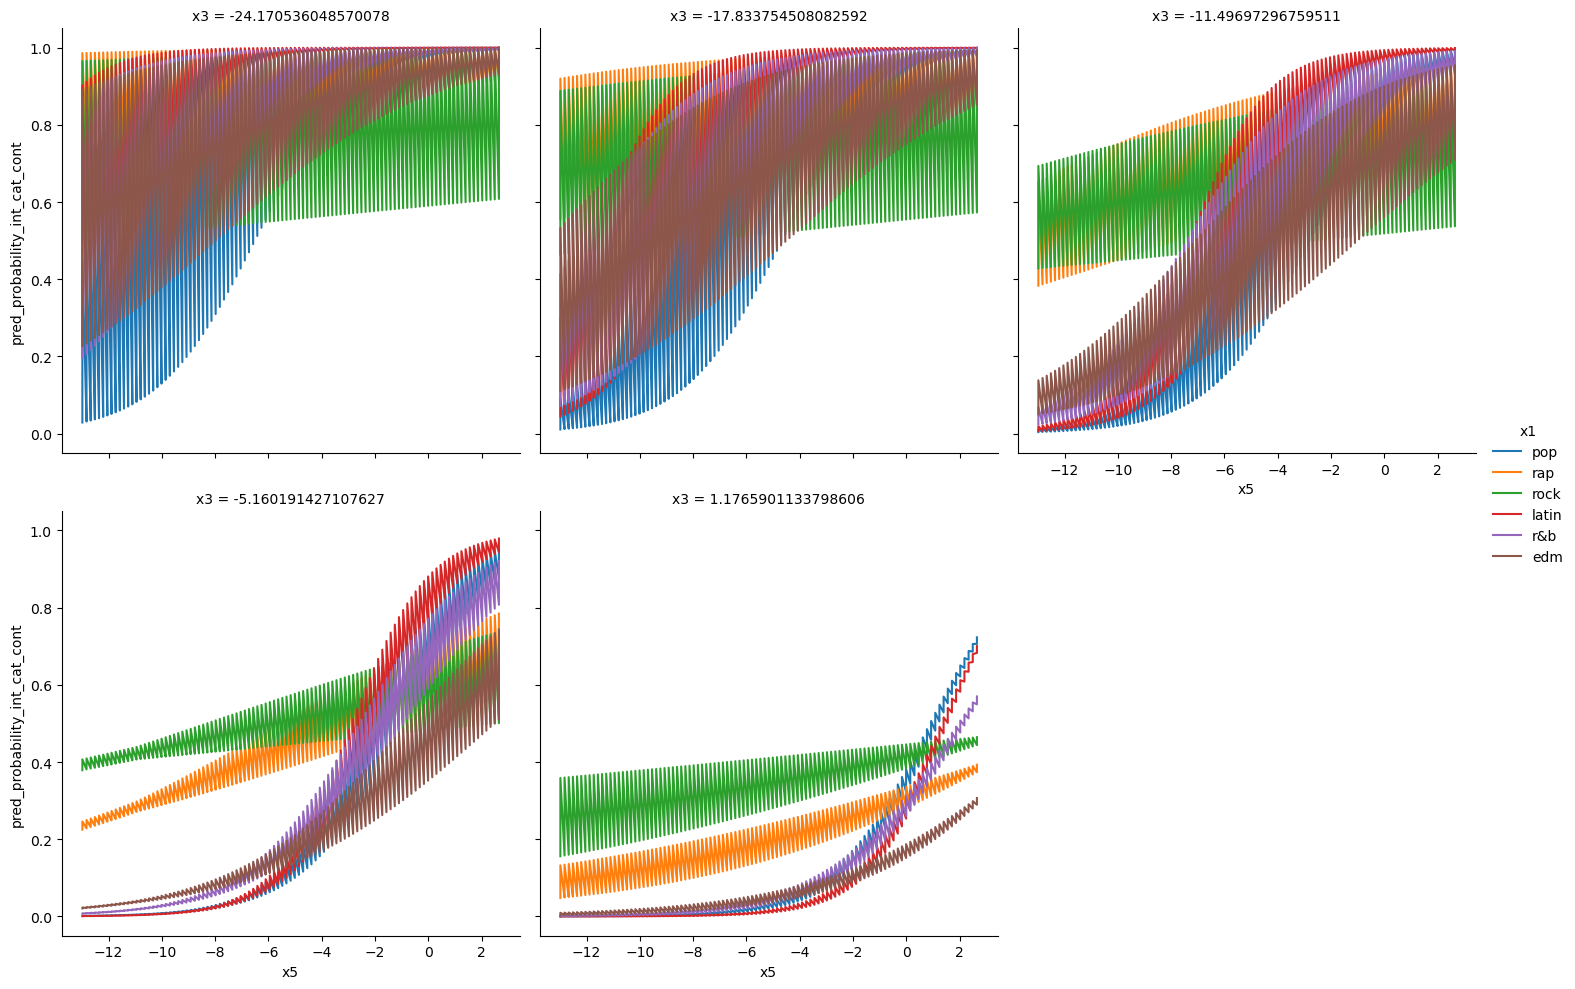

In [442]:
sns.relplot(data = df_viz, x='x5', y='pred_probability_int_cat_cont', hue='x1', col='x3',
            kind='line', estimator=None, units='x1',
            col_wrap=3)

plt.show()

## F. Models: Performance and Validation

### First, I'm creating a new dataframe that consists of NON STANDARDIZED and NON-logged values of my data. I'll redo both processes again before fitting my models with Sci-kit.

In [443]:
df_scikit = cleaned_df.copy()

In [444]:
for n in non_gauss_inputs:
    df_scikit[n] = np.where(df_scikit[n] <= 0, 0.01, df_scikit[n])

In [445]:
for input in range(len(non_gauss_inputs)):
    df_scikit[non_gauss_inputs[input]] = np.log(df_scikit[non_gauss_inputs[input]])

In [446]:
df_cross_val = df_scikit.rename(columns={'track_popularity' : 'y', 'playlist_genre' : 'x1', 
                                                 'danceability': 'x2', 'energy' : 'x3', 'key' : 'x4',
                                                 'loudness' : 'x5', 'mode' : 'x6', 'speechiness' : 'x7', 'acousticness' :'x8', 
                                                 'instrumentalness' : 'x9', 'liveness' : 'x10', 'valence' :'x11', 
                                                 'tempo' : 'x12', 'duration_ms' : 'x13'}).copy()

In [447]:
### Making a list that contains all my continuous inputs that I'll standardize later.
cross_cont_inputs = ['x2', 'x3', 'x5', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13']

### Statsmodels cross_valuation

In [448]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=101)

In [449]:
def train_and_test_cv(mod_name, a_formula, init_mod, data_df, cv):

    y, X = dmatrices( a_formula, data=data_df )
    
    train_res = []
    test_res = []
    
    for train_id, test_id in cv.split( X, y.ravel() ):
        # standardizing the inputs:
        data_df[cross_cont_inputs] = StandardScaler().fit_transform(data_df[cross_cont_inputs])
        
        X_train = X[train_id]
        X_test = X[test_id]
        
        y_train = y[train_id]
        y_test = y[test_id]
        
        fit_mod = init_mod.fit( X_train, y_train.ravel() )
        
        train_res.append( fit_mod.score( X_train, y_train.ravel() ) )
        test_res.append( fit_mod.score( X_test, y_test.ravel() ) )
    
    train_df = pd.DataFrame({'Accuracy': train_res})
    train_df['from_set'] = 'training'
    train_df['fold_id'] = train_df.index + 1
    
    test_df = pd.DataFrame({'Accuracy': test_res})
    test_df['from_set'] = 'testing'
    test_df['fold_id'] = test_df.index + 1
    
    res_df = pd.concat([train_df, test_df], ignore_index=True)
    
    res_df['model_name'] = mod_name
    res_df['model_formula'] = a_formula
    res_df['num_coefs'] = fit_mod.coef_.ravel().size
    
    return res_df

In [450]:
sk_min_loss = LogisticRegression(penalty=None, solver='lbfgs', fit_intercept=False, max_iter=25001)

### 1. Applying the function to my model that interacts categorical inputs with the continuous (highest accuracy)

In [451]:
model_1df = train_and_test_cv('interact_cat_cont', formula_list[5], sk_min_loss, df_cross_val, kf)

In [452]:
model_1df

,Accuracy,from_set,fold_id,model_name,model_formula,num_coefs
0,0.618156,training,1,interact_cat_cont,y ~ (x1 + x4 + x6) * (x2 + x3 + x5 + x7 + x8 +...,88
1,0.618129,training,2,interact_cat_cont,y ~ (x1 + x4 + x6) * (x2 + x3 + x5 + x7 + x8 +...,88
2,0.618129,training,3,interact_cat_cont,y ~ (x1 + x4 + x6) * (x2 + x3 + x5 + x7 + x8 +...,88
3,0.618129,training,4,interact_cat_cont,y ~ (x1 + x4 + x6) * (x2 + x3 + x5 + x7 + x8 +...,88
4,0.618129,training,5,interact_cat_cont,y ~ (x1 + x4 + x6) * (x2 + x3 + x5 + x7 + x8 +...,88
5,0.618047,testing,1,interact_cat_cont,y ~ (x1 + x4 + x6) * (x2 + x3 + x5 + x7 + x8 +...,88
6,0.618156,testing,2,interact_cat_cont,y ~ (x1 + x4 + x6) * (x2 + x3 + x5 + x7 + x8 +...,88
7,0.618156,testing,3,interact_cat_cont,y ~ (x1 + x4 + x6) * (x2 + x3 + x5 + x7 + x8 +...,88
8,0.618156,testing,4,interact_cat_cont,y ~ (x1 + x4 + x6) * (x2 + x3 + x5 + x7 + x8 +...,88
9,0.618156,testing,5,interact_cat_cont,y ~ (x1 + x4 + x6) * (x2 + x3 + x5 + x7 + x8 +...,88


### 2. Applying the function to a simple model (All additive inputs)

In [453]:
model_2df = train_and_test_cv('all_add', formula_list[3], sk_min_loss, df_cross_val, kf)

In [454]:
model_2df

,Accuracy,from_set,fold_id,model_name,model_formula,num_coefs
0,0.625795,training,1,all_add,y ~ x1 + x2 + x3 + x4 + x5 + x6 + x7 + x8 + x9...,18
1,0.626032,training,2,all_add,y ~ x1 + x2 + x3 + x4 + x5 + x6 + x7 + x8 + x9...,18
2,0.624134,training,3,all_add,y ~ x1 + x2 + x3 + x4 + x5 + x6 + x7 + x8 + x9...,18
3,0.624575,training,4,all_add,y ~ x1 + x2 + x3 + x4 + x5 + x6 + x7 + x8 + x9...,18
4,0.627445,training,5,all_add,y ~ x1 + x2 + x3 + x4 + x5 + x6 + x7 + x8 + x9...,18
5,0.623874,testing,1,all_add,y ~ x1 + x2 + x3 + x4 + x5 + x6 + x7 + x8 + x9...,18
6,0.625397,testing,2,all_add,y ~ x1 + x2 + x3 + x4 + x5 + x6 + x7 + x8 + x9...,18
7,0.626634,testing,3,all_add,y ~ x1 + x2 + x3 + x4 + x5 + x6 + x7 + x8 + x9...,18
8,0.626280,testing,4,all_add,y ~ x1 + x2 + x3 + x4 + x5 + x6 + x7 + x8 + x9...,18
9,0.618156,testing,5,all_add,y ~ x1 + x2 + x3 + x4 + x5 + x6 + x7 + x8 + x9...,18


### 3. Applying the function to a medium-high complexity model (my custom interaction between `playlist_genre` and the additive continuous inputs)

In [455]:
model_3df = train_and_test_cv('custom_int_add', formula_list[-1], sk_min_loss, df_cross_val, kf)

In [456]:
model_3df

,Accuracy,from_set,fold_id,model_name,model_formula,num_coefs
0,0.640675,training,1,custom_int_add,y ~ x1 * (x2 + x3 + x5 + x8 + x9 + x11 + x13),48
1,0.643384,training,2,custom_int_add,y ~ x1 * (x2 + x3 + x5 + x8 + x9 + x11 + x13),48
2,0.643384,training,3,custom_int_add,y ~ x1 * (x2 + x3 + x5 + x8 + x9 + x11 + x13),48
3,0.639896,training,4,custom_int_add,y ~ x1 * (x2 + x3 + x5 + x8 + x9 + x11 + x13),48
4,0.643296,training,5,custom_int_add,y ~ x1 * (x2 + x3 + x5 + x8 + x9 + x11 + x13),48
5,0.639237,testing,1,custom_int_add,y ~ x1 * (x2 + x3 + x5 + x8 + x9 + x11 + x13),48
6,0.634405,testing,2,custom_int_add,y ~ x1 * (x2 + x3 + x5 + x8 + x9 + x11 + x13),48
7,0.634228,testing,3,custom_int_add,y ~ x1 * (x2 + x3 + x5 + x8 + x9 + x11 + x13),48
8,0.649770,testing,4,custom_int_add,y ~ x1 * (x2 + x3 + x5 + x8 + x9 + x11 + x13),48
9,0.636701,testing,5,custom_int_add,y ~ x1 * (x2 + x3 + x5 + x8 + x9 + x11 + x13),48


#### Combining the dataframes so that I can plot their performance

In [457]:
results = [model_1df, model_2df, model_3df]

In [458]:
mod_results = pd.concat(results, ignore_index=True)

C:\Users\abene\AppData\Local\Temp\ipykernel_6732\2831498053.py:1: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.catplot(data = mod_results, x='model_name', y='Accuracy', hue='from_set', kind='point', join=False,
C:\Users\abene\anaconda3\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


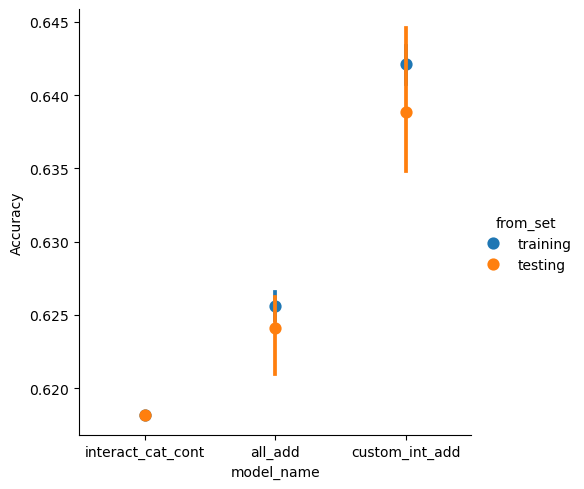

In [459]:
sns.catplot(data = mod_results, x='model_name', y='Accuracy', hue='from_set', kind='point', join=False,
            errorbar=('ci', 95))

plt.show()

The result of this cross-validation was quite surprising. Firstly, unlike the statsmodels fit, my custom model appears to be the most accurate on BOTH the training and testing data. `interact_cat_cont` was the most accurate using statsmodels but it appears to be the least accurate here on BOTH the training and testing data. In fact, the predictions for the training and testing data are so similar on that model that the figure doesn't even show the blue hue for the training set. The best model in this cross-validation had 48 coefficients, as opposed to 18 and 88 from the other models respectively.